# 人口変数なし raw_crop_wx 二段階LightGBM：Spatial OOF・残差・SHAP

人口密度と人口密度の周辺WXだけを除外した33変数モデルを、5-fold spatial OOFで再推定する。

- Stage 1：cropland presence classifier
- Stage 2：presenceセル内の cropland fraction regressor
- 評価：OOF R²、RMSE、MAE、bias、残差の空間分布、Moran's I
- 解釈：同じOOF分割で個別変数・概念グループのTree SHAP

人口変数は説明変数から除外するが、Fullモデルとの比較可能性を保つため、サンプル母集団の定義は既存モデルと揃える。


## セル番号・実行順

このノートブックは上から順番に全セルを実行する。

| セル | 内容 |
|---:|---|
| 0–3 | 方針、データ読み込み、WX作成 |
| 4–7 | raw crop potential作成と33変数の構成 |
| 8–11 | OOF予測、R²、残差、Moran's I、空間分布 |
| 12–15 | OOF Tree SHAPの計算と集計 |
| 16–18 | 個別変数・グループ別SHAPの表示 |

データ有無フラグは、今回は人口の影響だけを比較するため残している。


## セル2：データ読み込み

In [2]:
from __future__ import annotations

import gc
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
)
from sklearn.neighbors import BallTree
from lightgbm import LGBMClassifier, LGBMRegressor

warnings.filterwarnings("ignore", category=RuntimeWarning)

ROOT = Path(r"C:\masterresearch\Comparative_advantage")
GAEZ_DIR = ROOT / "GAEZ"
HYDE_DIR = ROOT / "HYDE3.4"
CROPLAND_DIR = HYDE_DIR / "cropland_npys"
DIST_DIR = ROOT / "distance_to_cities"
GLOFAS_DIR = ROOT / "GloFAS" / "processed_5min"
FEATURE_CACHE = GAEZ_DIR / "CroplandRegression" / "features_cache"
OUTPUT_DIR = GAEZ_DIR / "CroplandRegression" / "spatial_wx_comparison"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
YEAR = 2024
PRESENCE_THRESHOLD = 0.01
N_POS_SAMPLE = 120_000
N_ZERO_SAMPLE = 120_000
N_SPLITS = 5

WX_RADII_KM = (50, 100)
WX_SOURCE_FEATURES = [
    "log_city_time_20k_min",
    "log_port_time_any_min",
    "log_rainfed_value_top5",
    "log_glofas_p10_2020",
    "log_distance_river_gt10_2020",
]
INCLUDE_SLOPE_WX = False
MIN_VALID_NEIGHBOR_FRACTION = 0.25
SAVE_WX_RASTERS = True

EARTH_RADIUS_KM = 6371.0088
MORAN_K = 8
MORAN_MAX_N = 50_000


def load_cache(*names):
    for name in names:
        path = FEATURE_CACHE / name
        if path.exists():
            print("load cache:", path.name)
            return np.load(path, mmap_mode="r")
    raise FileNotFoundError(
        "Required cache not found: " + ", ".join(names)
    )


def safe_log1p(values):
    values = np.asarray(values, dtype=np.float32)
    values = np.where(np.isfinite(values) & (values > 0), values, 0.0)
    return np.log1p(values).astype(np.float32)


lat = np.load(CROPLAND_DIR / "lat.npy")
lon = np.load(CROPLAND_DIR / "lon.npy")
SHAPE = (len(lat), len(lon))

cropland_raw = np.load(
    CROPLAND_DIR / "cropland_fraction_1950_2024.npy",
    mmap_mode="r",
)
years = np.load(CROPLAND_DIR / "years.npy")
year_index = int(np.where(years == YEAR)[0][0])
cropland_2024 = np.asarray(cropland_raw[year_index], dtype=np.float32).copy()
cropland_2024[~np.isfinite(cropland_2024)] = np.nan

population_density_2024 = load_cache("population_density_2024.npy")
elevation_m = load_cache("elevation_5min.npy")
slope = load_cache("slope_5min.npy")
exclusion = load_cache("exclusion_5min_mode.npy")
city_time_20k_min = np.load(DIST_DIR / "cities_10_1_12deg_min.npy", mmap_mode="r")
port_time_any_min = np.load(DIST_DIR / "ports_05_1_12deg_min.npy", mmap_mode="r")
glofas_p10 = np.load(GLOFAS_DIR / "p10_discharge_max_5min_2020.npy", mmap_mode="r")
distance_river_gt10 = np.load(
    GLOFAS_DIR / "distance_to_reliable_river_p10_gt_10_m3s_km_5min_2020.npy",
    mmap_mode="r",
)
rainfed_value_top5 = load_cache(
    "rainfed_value_top5_usd_per_ha_checked_36crops.npy",
    "rainfed_value_top5_checked_36crops.npy",
)
irrigated_value_top5 = load_cache(
    "irrigated_value_top5_usd_per_ha_checked_36crops.npy",
    "irrigated_value_top5_checked_36crops.npy",
)
rainfed_calorie_top5 = load_cache(
    "rainfed_calorie_top5_kcal_per_ha_checked_36crops.npy",
    "rainfed_calorie_top5_checked_36crops.npy",
)
irrigated_calorie_top5 = load_cache(
    "irrigated_calorie_top5_kcal_per_ha_checked_36crops.npy",
    "irrigated_calorie_top5_checked_36crops.npy",
)

land_mask = (
    np.isfinite(elevation_m)
    & np.isfinite(cropland_2024)
    & np.isfinite(population_density_2024)
    & (population_density_2024 >= 0)
)
presence = land_mask & (cropland_2024 > PRESENCE_THRESHOLD)

rng = np.random.default_rng(RANDOM_SEED)
pos_flat = np.flatnonzero(presence.ravel())
zero_flat = np.flatnonzero((land_mask & ~presence).ravel())
pos_sample = rng.choice(pos_flat, min(N_POS_SAMPLE, len(pos_flat)), replace=False)
zero_sample = rng.choice(zero_flat, min(N_ZERO_SAMPLE, len(zero_flat)), replace=False)
sample_flat = np.concatenate([pos_sample, zero_sample])
rng.shuffle(sample_flat)
rows, cols = np.unravel_index(sample_flat, SHAPE)


def take(array):
    return np.asarray(array[rows, cols])


sample = pd.DataFrame({
    "row": rows.astype(np.int32),
    "col": cols.astype(np.int32),
    "lat": lat[rows].astype(np.float32),
    "lon": lon[cols].astype(np.float32),
    "cropland_fraction": take(cropland_2024).astype(np.float32),
    "presence": (take(cropland_2024) > PRESENCE_THRESHOLD).astype(np.uint8),
    "elevation_m": take(elevation_m).astype(np.float32),
    "slope": take(slope).astype(np.float32),
    "exclusion_class": np.nan_to_num(take(exclusion), nan=-1).astype(np.int16),
    "log_pop_density_2024": safe_log1p(take(population_density_2024)),
    "log_city_time_20k_min": safe_log1p(take(city_time_20k_min)),
    "log_port_time_any_min": safe_log1p(take(port_time_any_min)),
    "log_glofas_p10_2020": safe_log1p(take(glofas_p10)),
    "log_distance_river_gt10_2020": safe_log1p(take(distance_river_gt10)),
    "log_rainfed_value_top5": safe_log1p(take(rainfed_value_top5)),
    "log_rainfed_calorie_top5": safe_log1p(take(rainfed_calorie_top5)),
    "log_irrigation_value_gain_top5": safe_log1p(
        np.maximum(take(irrigated_value_top5) - take(rainfed_value_top5), 0)
    ),
    "log_irrigation_calorie_gain_top5": safe_log1p(
        np.maximum(take(irrigated_calorie_top5) - take(rainfed_calorie_top5), 0)
    ),
}).replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

sample["spatial_block"] = (
    np.floor((sample["lat"] + 90) / 10).astype(int) * 36
    + np.floor((sample["lon"] + 180) / 10).astype(int)
)

base_feature_cols = [
    "elevation_m",
    "slope",
    "exclusion_class",
    "log_pop_density_2024",
    "log_city_time_20k_min",
    "log_port_time_any_min",
    "log_glofas_p10_2020",
    "log_distance_river_gt10_2020",
    "log_rainfed_value_top5",
    "log_rainfed_calorie_top5",
    "log_irrigation_value_gain_top5",
    "log_irrigation_calorie_gain_top5",
]

print("grid:", SHAPE)
print("sample rows:", len(sample))
print("sample presence share:", float(sample["presence"].mean()))

load cache: population_density_2024.npy
load cache: elevation_5min.npy
load cache: slope_5min.npy
load cache: exclusion_5min_mode.npy
load cache: rainfed_value_top5_usd_per_ha_checked_36crops.npy
load cache: irrigated_value_top5_usd_per_ha_checked_36crops.npy
load cache: rainfed_calorie_top5_kcal_per_ha_checked_36crops.npy
load cache: irrigated_calorie_top5_kcal_per_ha_checked_36crops.npy
grid: (2160, 4320)
sample rows: 240000
sample presence share: 0.5


## セル3：周辺変数WXの準備

In [3]:
def _rolling_sum_horizontal(values, half_width):
    values = np.asarray(values, dtype=np.float32)
    if half_width <= 0:
        return values.copy()
    extended = np.concatenate(
        [values[:, -half_width:], values, values[:, :half_width]],
        axis=1,
    )
    width = 2 * half_width + 1
    cumulative = np.concatenate(
        [
            np.zeros((values.shape[0], 1), dtype=np.float64),
            np.cumsum(extended, axis=1, dtype=np.float64),
        ],
        axis=1,
    )
    return (cumulative[:, width:] - cumulative[:, :-width]).astype(np.float32)


def _rolling_sum_vertical(values, half_width):
    values = np.asarray(values, dtype=np.float32)
    if half_width <= 0:
        return values.copy()
    padded = np.pad(values, ((half_width, half_width), (0, 0)), mode="edge")
    width = 2 * half_width + 1
    cumulative = np.concatenate(
        [
            np.zeros((1, values.shape[1]), dtype=np.float64),
            np.cumsum(padded, axis=0, dtype=np.float64),
        ],
        axis=0,
    )
    return (cumulative[width:, :] - cumulative[:-width, :]).astype(np.float32)


def latitude_aware_box_mean(values, lat_values, radius_km, min_valid_fraction=0.25):
    values = np.asarray(values, dtype=np.float32)
    if values.shape != SHAPE:
        raise ValueError(f"Unexpected raster shape: {values.shape}; expected {SHAPE}")

    lat_step_deg = float(np.median(np.abs(np.diff(lat_values))))
    lon_step_deg = float(np.median(np.abs(np.diff(lon))))
    km_per_degree = EARTH_RADIUS_KM * np.pi / 180.0
    half_lat = max(1, int(np.ceil(radius_km / (km_per_degree * lat_step_deg))))

    cos_lat = np.clip(np.cos(np.deg2rad(lat_values)), 1e-6, None)
    half_lon_by_row = np.ceil(
        radius_km / (km_per_degree * cos_lat * lon_step_deg)
    ).astype(np.int32)
    half_lon_by_row = np.minimum(half_lon_by_row, values.shape[1] // 2 - 1)

    finite = np.isfinite(values)
    filled = np.where(finite, values, 0).astype(np.float32)
    counts = finite.astype(np.float32)
    horizontal_sum = np.zeros_like(filled, dtype=np.float32)
    horizontal_count = np.zeros_like(counts, dtype=np.float32)

    for half_lon in np.unique(half_lon_by_row):
        row_indices = np.flatnonzero(half_lon_by_row == half_lon)
        horizontal_sum[row_indices] = _rolling_sum_horizontal(
            filled[row_indices], int(half_lon)
        )
        horizontal_count[row_indices] = _rolling_sum_horizontal(
            counts[row_indices], int(half_lon)
        )

    vertical_sum = _rolling_sum_vertical(horizontal_sum, half_lat)
    vertical_count = _rolling_sum_vertical(horizontal_count, half_lat)

    row_width = (2 * half_lon_by_row + 1).astype(np.float64)
    padded_width = np.pad(row_width, (half_lat, half_lat), mode="edge")
    cumulative_width = np.concatenate([[0.0], np.cumsum(padded_width)])
    window_width_by_row = (
        cumulative_width[2 * half_lat + 1:]
        - cumulative_width[:-(2 * half_lat + 1)]
    )
    minimum_count = min_valid_fraction * window_width_by_row

    result = np.full(values.shape, np.nan, dtype=np.float32)
    valid = vertical_count >= minimum_count[:, None]
    with np.errstate(divide="ignore", invalid="ignore"):
        result[valid] = (vertical_sum[valid] / vertical_count[valid]).astype(np.float32)
    return result


wx_source_rasters = {
    "log_pop_density_2024": population_density_2024,
    "log_city_time_20k_min": city_time_20k_min,
    "log_port_time_any_min": port_time_any_min,
    "log_rainfed_value_top5": rainfed_value_top5,
    "log_glofas_p10_2020": glofas_p10,
    "log_distance_river_gt10_2020": distance_river_gt10,
}
if INCLUDE_SLOPE_WX:
    wx_source_rasters["slope"] = slope
    WX_SOURCE_FEATURES = WX_SOURCE_FEATURES + ["slope"]

sample_rows = sample["row"].to_numpy(dtype=int)
sample_cols = sample["col"].to_numpy(dtype=int)
wx_feature_cols = []

for radius_km in WX_RADII_KM:
    for source_name in WX_SOURCE_FEATURES:
        wx_name = f"wx_{radius_km}km_{source_name}"
        cache_path = OUTPUT_DIR / f"{wx_name}.npy"

        if cache_path.exists():
            print("load WX cache:", cache_path.name)
            wx_raster = np.load(cache_path, mmap_mode="r")
        else:
            print("build WX:", wx_name)
            if source_name == "slope":
                source_values = np.asarray(wx_source_rasters[source_name], dtype=np.float32)
            else:
                source_values = safe_log1p(wx_source_rasters[source_name])
            wx_raster = latitude_aware_box_mean(
                source_values,
                lat,
                radius_km,
                min_valid_fraction=MIN_VALID_NEIGHBOR_FRACTION,
            )
            if SAVE_WX_RASTERS:
                np.save(cache_path, wx_raster.astype(np.float32, copy=False))

        sample[wx_name] = np.asarray(
            wx_raster[sample_rows, sample_cols],
            dtype=np.float32,
        )
        wx_feature_cols.append(wx_name)

        if "source_values" in locals():
            del source_values
        if not SAVE_WX_RASTERS and not isinstance(wx_raster, np.memmap):
            del wx_raster
        gc.collect()

print("WX feature count:", len(wx_feature_cols))

load WX cache: wx_50km_log_city_time_20k_min.npy
load WX cache: wx_50km_log_port_time_any_min.npy
load WX cache: wx_50km_log_rainfed_value_top5.npy
load WX cache: wx_50km_log_glofas_p10_2020.npy
load WX cache: wx_50km_log_distance_river_gt10_2020.npy
load WX cache: wx_100km_log_city_time_20k_min.npy
load WX cache: wx_100km_log_port_time_any_min.npy
load WX cache: wx_100km_log_rainfed_value_top5.npy
load WX cache: wx_100km_log_glofas_p10_2020.npy
load WX cache: wx_100km_log_distance_river_gt10_2020.npy
WX feature count: 10


## セル4：Spatial OOFの準備

In [4]:
sample = (
    sample.replace([np.inf, -np.inf], np.nan)
    .dropna(subset=base_feature_cols + wx_feature_cols)
    .reset_index(drop=True)
)
analysis_sample = sample.copy()
y_all = analysis_sample["presence"].to_numpy(dtype=np.uint8)
groups = analysis_sample["spatial_block"].to_numpy()

if analysis_sample["presence"].nunique() < 2:
    raise ValueError("Both presence classes are required.")
target_prior = float(presence.sum() / land_mask.sum())

feature_cols_by_model = {
    "baseline": base_feature_cols,
    "wx": base_feature_cols + wx_feature_cols,
}

try:
    cell_area_km2 = np.load(CROPLAND_DIR / "grid_area_km2.npy", mmap_mode="r")
    sample_area = np.asarray(
        cell_area_km2[
            analysis_sample["row"].to_numpy(int),
            analysis_sample["col"].to_numpy(int),
        ],
        dtype=float,
    )
    n_pos_pop = int(presence.sum())
    n_zero_pop = int(land_mask.sum() - presence.sum())
    n_pos_samp = int((y_all == 1).sum())
    n_zero_samp = int((y_all == 0).sum())
    area_weight = np.where(
        y_all == 1,
        n_pos_pop / max(n_pos_samp, 1),
        n_zero_pop / max(n_zero_samp, 1),
    ) * sample_area
except FileNotFoundError:
    print("grid_area_km2.npy not found; area weighting skipped.")
    area_weight = None

splits = list(
    GroupKFold(n_splits=N_SPLITS).split(
        analysis_sample,
        y_all,
        groups=groups,
    )
)
print("analysis rows:", len(analysis_sample))
print("spatial blocks:", analysis_sample["spatial_block"].nunique())
print("target prior:", target_prior)

analysis rows: 240000
spatial blocks: 291
target prior: 0.3658932992121897


## セル5：raw crop potential変数の作成

crop potentialはraw値を使い、存在・欠測フラグと灌漑の符号付きdeltaを追加する。

In [5]:
raw_analysis_sample = analysis_sample.copy()

raw_rows = raw_analysis_sample["row"].to_numpy(dtype=int)
raw_cols = raw_analysis_sample["col"].to_numpy(dtype=int)


def sample_raster(array):
    return np.asarray(
        array[raw_rows, raw_cols],
        dtype=np.float32,
    )


def clean_positive_feature(values):
    """
    正の値だけをraw値として残す。
    非正値は0にする。
    同時に、存在フラグと欠測フラグも返す。
    """
    values = np.asarray(values, dtype=np.float32)

    finite = np.isfinite(values)
    exists = finite & (values > 0)
    missing = ~finite

    clean = np.where(
        exists,
        values,
        0.0,
    ).astype(np.float32)

    return (
        clean,
        exists.astype(np.uint8),
        missing.astype(np.uint8),
    )


# ------------------------------------------------------------
# 2. crop potentialのraw値を作成
# ------------------------------------------------------------

rainfed_value_sample = sample_raster(rainfed_value_top5)
irrigated_value_sample = sample_raster(irrigated_value_top5)

rainfed_calorie_sample = sample_raster(rainfed_calorie_top5)
irrigated_calorie_sample = sample_raster(irrigated_calorie_top5)


(
    rainfed_value_raw,
    rainfed_value_exists,
    rainfed_value_missing,
) = clean_positive_feature(rainfed_value_sample)

(
    rainfed_calorie_raw,
    rainfed_calorie_exists,
    rainfed_calorie_missing,
) = clean_positive_feature(rainfed_calorie_sample)


# ------------------------------------------------------------
# 3. 灌漑gainと符号付き差分を作成
# ------------------------------------------------------------

value_pair_valid = (
    np.isfinite(rainfed_value_sample)
    & np.isfinite(irrigated_value_sample)
)

calorie_pair_valid = (
    np.isfinite(rainfed_calorie_sample)
    & np.isfinite(irrigated_calorie_sample)
)


# 符号付き差分
irrigation_value_delta_signed = np.where(
    value_pair_valid,
    irrigated_value_sample - rainfed_value_sample,
    0.0,
).astype(np.float32)

irrigation_calorie_delta_signed = np.where(
    calorie_pair_valid,
    irrigated_calorie_sample - rainfed_calorie_sample,
    0.0,
).astype(np.float32)


# 非負gain
irrigation_value_gain_raw = np.maximum(
    irrigation_value_delta_signed,
    0.0,
).astype(np.float32)

irrigation_calorie_gain_raw = np.maximum(
    irrigation_calorie_delta_signed,
    0.0,
).astype(np.float32)


# gainの存在フラグ
irrigation_value_gain_exists = (
    value_pair_valid
    & (irrigation_value_delta_signed > 0)
).astype(np.uint8)

irrigation_calorie_gain_exists = (
    calorie_pair_valid
    & (irrigation_calorie_delta_signed > 0)
).astype(np.uint8)


# 欠測フラグ
irrigation_value_gain_missing = (
    ~value_pair_valid
).astype(np.uint8)

irrigation_calorie_gain_missing = (
    ~calorie_pair_valid
).astype(np.uint8)


# ------------------------------------------------------------
# 4. DataFrameに追加
# ------------------------------------------------------------

raw_analysis_sample[
    "rainfed_value_top5_raw"
] = rainfed_value_raw

raw_analysis_sample[
    "rainfed_calorie_top5_raw"
] = rainfed_calorie_raw

raw_analysis_sample[
    "irrigation_value_gain_top5_raw"
] = irrigation_value_gain_raw

raw_analysis_sample[
    "irrigation_calorie_gain_top5_raw"
] = irrigation_calorie_gain_raw


raw_analysis_sample[
    "rainfed_value_top5_exists"
] = rainfed_value_exists

raw_analysis_sample[
    "rainfed_calorie_top5_exists"
] = rainfed_calorie_exists

raw_analysis_sample[
    "irrigation_value_gain_top5_exists"
] = irrigation_value_gain_exists

raw_analysis_sample[
    "irrigation_calorie_gain_top5_exists"
] = irrigation_calorie_gain_exists


raw_analysis_sample[
    "irrigation_value_delta_top5_signed"
] = irrigation_value_delta_signed

raw_analysis_sample[
    "irrigation_calorie_delta_top5_signed"
] = irrigation_calorie_delta_signed


raw_analysis_sample[
    "rainfed_value_top5_missing"
] = rainfed_value_missing

raw_analysis_sample[
    "rainfed_calorie_top5_missing"
] = rainfed_calorie_missing

raw_analysis_sample[
    "irrigation_value_gain_top5_missing"
] = irrigation_value_gain_missing

raw_analysis_sample[
    "irrigation_calorie_gain_top5_missing"
] = irrigation_calorie_gain_missing


# ------------------------------------------------------------
# 5. 新しいcrop potential feature list
# ------------------------------------------------------------

non_crop_base_cols = [
    "elevation_m",
    "slope",
    "exclusion_class",
    "log_city_time_20k_min",
    "log_port_time_any_min",
    "log_glofas_p10_2020",
    "log_distance_river_gt10_min",
]

# 実際の列名を確認
if "log_distance_river_gt10_min" not in raw_analysis_sample.columns:
    non_crop_base_cols[-1] = "log_distance_river_gt10_2020"


raw_crop_cols = [
    # rawの大きさ
    "rainfed_value_top5_raw",
    "rainfed_calorie_top5_raw",
    "irrigation_value_gain_top5_raw",
    "irrigation_calorie_gain_top5_raw",

    # 0か正値か
    "rainfed_value_top5_exists",
    "rainfed_calorie_top5_exists",
    "irrigation_value_gain_top5_exists",
    "irrigation_calorie_gain_top5_exists",

    # 灌漑による符号付き差分
    "irrigation_value_delta_top5_signed",
    "irrigation_calorie_delta_top5_signed",

    # 欠測フラグ
    "rainfed_value_top5_missing",
    "rainfed_calorie_top5_missing",
    "irrigation_value_gain_top5_missing",
    "irrigation_calorie_gain_top5_missing",
]


raw_crop_feature_cols = (
    non_crop_base_cols
    + raw_crop_cols
)


# ------------------------------------------------------------
# 6. raw版のcrop potential WXを作る
# ------------------------------------------------------------

raw_rainfed_value_raster = np.asarray(
    rainfed_value_top5,
    dtype=np.float32,
)

raw_rainfed_value_valid = np.isfinite(
    raw_rainfed_value_raster
)

raw_rainfed_value_clean_raster = np.where(
    raw_rainfed_value_valid
    & (raw_rainfed_value_raster > 0),
    raw_rainfed_value_raster,
    0.0,
).astype(np.float32)

raw_rainfed_value_exists_raster = (
    raw_rainfed_value_valid
    & (raw_rainfed_value_raster > 0)
).astype(np.float32)


raw_crop_wx_feature_cols = []

for radius_km in WX_RADII_KM:

    raw_wx_specs = [
        (
            f"wx_{radius_km}km_rainfed_value_top5_raw",
            raw_rainfed_value_clean_raster,
        ),
        (
            f"wx_{radius_km}km_rainfed_value_exists_share",
            raw_rainfed_value_exists_raster,
        ),
    ]

    for wx_name, source_values in raw_wx_specs:

        cache_path = (
            OUTPUT_DIR
            / f"{wx_name}.npy"
        )

        if cache_path.exists():
            print("load raw WX cache:", cache_path.name)
            wx_raster = np.load(
                cache_path,
                mmap_mode="r",
            )
        else:
            print("build raw WX:", wx_name)

            wx_raster = latitude_aware_box_mean(
                source_values,
                lat,
                radius_km,
                min_valid_fraction=MIN_VALID_NEIGHBOR_FRACTION,
            )

            if SAVE_WX_RASTERS:
                np.save(
                    cache_path,
                    wx_raster.astype(
                        np.float32,
                        copy=False,
                    ),
                )

        raw_analysis_sample[wx_name] = np.asarray(
            wx_raster[raw_rows, raw_cols],
            dtype=np.float32,
        )

        raw_crop_wx_feature_cols.append(wx_name)


# 既存WXから、log版rainfed value WXだけ除外
non_crop_wx_feature_cols = [
    col
    for col in wx_feature_cols
    if "log_rainfed_value_top5" not in col
]


raw_crop_wx_feature_cols = (
    raw_crop_feature_cols
    + non_crop_wx_feature_cols
    + raw_crop_wx_feature_cols
)


feature_cols_raw_by_model = {
    "raw_crop": raw_crop_feature_cols,
    "raw_crop_wx": raw_crop_wx_feature_cols,
}


print()
print("raw_crop feature count:", len(raw_crop_feature_cols))
print("raw_crop_wx feature count:", len(raw_crop_wx_feature_cols))
print()
print("raw_crop features:")
print(raw_crop_feature_cols)
print()
print("raw_crop_wx features:")
print(raw_crop_wx_feature_cols)


# ------------------------------------------------------------

load raw WX cache: wx_50km_rainfed_value_top5_raw.npy
load raw WX cache: wx_50km_rainfed_value_exists_share.npy
load raw WX cache: wx_100km_rainfed_value_top5_raw.npy
load raw WX cache: wx_100km_rainfed_value_exists_share.npy

raw_crop feature count: 21
raw_crop_wx feature count: 33

raw_crop features:
['elevation_m', 'slope', 'exclusion_class', 'log_city_time_20k_min', 'log_port_time_any_min', 'log_glofas_p10_2020', 'log_distance_river_gt10_2020', 'rainfed_value_top5_raw', 'rainfed_calorie_top5_raw', 'irrigation_value_gain_top5_raw', 'irrigation_calorie_gain_top5_raw', 'rainfed_value_top5_exists', 'rainfed_calorie_top5_exists', 'irrigation_value_gain_top5_exists', 'irrigation_calorie_gain_top5_exists', 'irrigation_value_delta_top5_signed', 'irrigation_calorie_delta_top5_signed', 'rainfed_value_top5_missing', 'rainfed_calorie_top5_missing', 'irrigation_value_gain_top5_missing', 'irrigation_calorie_gain_top5_missing']

raw_crop_wx features:
['elevation_m', 'slope', 'exclusion_class', 'l

## セル7：人口変数なし33変数の確認

36変数の raw_crop_wx から、以下の3変数だけを除外している。

 - log_pop_density_2024
 - wx_50km_log_pop_density_2024
 - wx_100km_log_pop_density_2024

データ有無フラグは残し、人口の有無だけを比較する。


In [6]:
RAW_WX_SHAP_MODEL = "raw_crop_wx_no_population"
RAW_WX_SHAP_FEATURES = list(feature_cols_raw_by_model["raw_crop_wx"])
print("model:", RAW_WX_SHAP_MODEL)
print("feature count:", len(RAW_WX_SHAP_FEATURES))
print(RAW_WX_SHAP_FEATURES)

model: raw_crop_wx_no_population
feature count: 33
['elevation_m', 'slope', 'exclusion_class', 'log_city_time_20k_min', 'log_port_time_any_min', 'log_glofas_p10_2020', 'log_distance_river_gt10_2020', 'rainfed_value_top5_raw', 'rainfed_calorie_top5_raw', 'irrigation_value_gain_top5_raw', 'irrigation_calorie_gain_top5_raw', 'rainfed_value_top5_exists', 'rainfed_calorie_top5_exists', 'irrigation_value_gain_top5_exists', 'irrigation_calorie_gain_top5_exists', 'irrigation_value_delta_top5_signed', 'irrigation_calorie_delta_top5_signed', 'rainfed_value_top5_missing', 'rainfed_calorie_top5_missing', 'irrigation_value_gain_top5_missing', 'irrigation_calorie_gain_top5_missing', 'wx_50km_log_city_time_20k_min', 'wx_50km_log_port_time_any_min', 'wx_50km_log_glofas_p10_2020', 'wx_50km_log_distance_river_gt10_2020', 'wx_100km_log_city_time_20k_min', 'wx_100km_log_port_time_any_min', 'wx_100km_log_glofas_p10_2020', 'wx_100km_log_distance_river_gt10_2020', 'wx_50km_rainfed_value_top5_raw', 'wx_50km_r

## セル8：OOF用モデルとTree SHAPの共通関数


In [7]:
import shap

SHAP_MAX_ROWS_PER_FOLD = 10_000
SHAP_OUTPUT_DIR = OUTPUT_DIR / "no_population_raw_crop_wx_oof_shap"
SHAP_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def fit_models(train_df, features, fold_number):
    classifier = LGBMClassifier(
        objective="binary", n_estimators=450, learning_rate=0.035,
        num_leaves=31, min_child_samples=80, subsample=0.85,
        colsample_bytree=0.85, random_state=RANDOM_SEED + fold_number,
        n_jobs=4, verbose=-1,
    )
    classifier.fit(
        train_df[features], train_df["presence"],
        categorical_feature=["exclusion_class"],
    )
    positive_train = train_df[train_df["presence"].eq(1)]
    regressor = LGBMRegressor(
        objective="regression", n_estimators=550, learning_rate=0.03,
        num_leaves=31, min_child_samples=60, subsample=0.85,
        colsample_bytree=0.85, random_state=RANDOM_SEED + fold_number,
        n_jobs=4, verbose=-1,
    )
    regressor.fit(
        positive_train[features],
        positive_train["cropland_fraction"],
        categorical_feature=["exclusion_class"],
    )
    return classifier, regressor


def choose_indices(indices, max_rows, seed):
    indices = np.asarray(indices, dtype=int)
    if max_rows is None or len(indices) <= max_rows:
        return np.sort(indices)
    rng = np.random.default_rng(seed)
    return np.sort(rng.choice(indices, size=max_rows, replace=False))


def tree_shap_raw(model, frame, features):
    values = shap.TreeExplainer(
        model,
        feature_perturbation="tree_path_dependent",
        model_output="raw",
    ).shap_values(frame[features], check_additivity=False)
    if isinstance(values, list):
        values = values[1] if len(values) == 2 else values[0]
    values = np.asarray(values)
    if values.ndim == 3:
        values = values[:, :, -1]
    if values.ndim != 2 or values.shape[1] != len(features):
        raise ValueError(f"Unexpected SHAP shape: {values.shape}")
    return values.astype(np.float32, copy=False)


def stats(values, indices):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(area_weight, dtype=float)[indices]
    valid = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    values, weights = values[valid], weights[valid]
    if len(values) == 0:
        return {"n": 0, "weight_sum": 0.0, "abs_num": 0.0, "signed_num": 0.0}
    return {
        "n": int(len(values)),
        "weight_sum": float(weights.sum()),
        "abs_num": float(np.sum(weights * np.abs(values))),
        "signed_num": float(np.sum(weights * values)),
    }

c:\Users\tsuda\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## セル9：人口変数なし33変数のSpatial OOF予測・評価

ここで計算するR²、RMSE、MAE、残差は、すべて学習に使っていないOOF予測に基づく。


In [8]:
# ============================================================
# 人口変数なし raw_crop_wx：5-fold spatial OOF
# ============================================================

NO_POP_MODEL_NAME = "raw_crop_wx_no_population"
NO_POP_FEATURES = list(feature_cols_raw_by_model["raw_crop_wx"])
NO_POP_OUTPUT_DIR = OUTPUT_DIR / "no_population_raw_crop_wx_oof_shap"
NO_POP_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if len(NO_POP_FEATURES) != 33:
    raise ValueError(f"人口変数なしモデルは33変数の想定ですが、{len(NO_POP_FEATURES)}変数です。")

for forbidden in [
    "log_pop_density_2024",
    "wx_50km_log_pop_density_2024",
    "wx_100km_log_pop_density_2024",
]:
    if forbidden in NO_POP_FEATURES:
        raise ValueError(f"人口変数が残っています: {forbidden}")


def adjust_probability_prior_shift(probability, sample_prior, target_prior, eps=1e-6):
    probability = np.clip(np.asarray(probability, dtype=float), eps, 1 - eps)
    sample_prior = float(np.clip(sample_prior, eps, 1 - eps))
    target_prior = float(np.clip(target_prior, eps, 1 - eps))
    odds = probability / (1.0 - probability)
    odds *= (target_prior / (1.0 - target_prior)) / (sample_prior / (1.0 - sample_prior))
    return odds / (1.0 + odds)


def regression_metrics(y_true, y_pred, weights=None):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    valid = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true, y_pred = y_true[valid], y_pred[valid]
    if weights is None:
        weights = np.ones(len(y_true), dtype=float)
    else:
        weights = np.asarray(weights, dtype=float)[valid]
    mean_true = np.average(y_true, weights=weights)
    residual = y_true - y_pred
    ss_res = np.sum(weights * residual ** 2)
    ss_tot = np.sum(weights * (y_true - mean_true) ** 2)
    return {
        "n": int(len(y_true)),
        "observed_mean": float(mean_true),
        "predicted_mean": float(np.average(y_pred, weights=weights)),
        "mae": float(np.average(np.abs(residual), weights=weights)),
        "rmse": float(np.sqrt(np.average(residual ** 2, weights=weights))),
        "r2": float(1.0 - ss_res / ss_tot) if ss_tot > 0 else np.nan,
        "bias_observed_minus_predicted": float(np.average(residual, weights=weights)),
    }


no_pop_oof = {
    "fold": np.full(len(raw_analysis_sample), -1, dtype=np.int16),
    "presence_probability_raw": np.full(len(raw_analysis_sample), np.nan, dtype=np.float32),
    "presence_probability_calibrated": np.full(len(raw_analysis_sample), np.nan, dtype=np.float32),
    "fraction_positive_conditional": np.full(len(raw_analysis_sample), np.nan, dtype=np.float32),
    "fraction_expected_oof": np.full(len(raw_analysis_sample), np.nan, dtype=np.float32),
}
no_pop_fold_rows = []

for fold_number, (train_idx, test_idx) in enumerate(splits, start=1):
    print(f"OOF fold {fold_number}/{N_SPLITS}")
    train_df = raw_analysis_sample.iloc[train_idx].copy()
    test_df = raw_analysis_sample.iloc[test_idx].copy()

    classifier, regressor = fit_models(train_df, NO_POP_FEATURES, fold_number)
    raw_probability = classifier.predict_proba(test_df[NO_POP_FEATURES])[:, 1]
    calibrated_probability = adjust_probability_prior_shift(
        raw_probability, float(train_df["presence"].mean()), target_prior
    )
    conditional = np.clip(regressor.predict(test_df[NO_POP_FEATURES]), 0.0, 1.0)
    expected = calibrated_probability * conditional

    no_pop_oof["fold"][test_idx] = fold_number
    no_pop_oof["presence_probability_raw"][test_idx] = raw_probability
    no_pop_oof["presence_probability_calibrated"][test_idx] = calibrated_probability
    no_pop_oof["fraction_positive_conditional"][test_idx] = conditional
    no_pop_oof["fraction_expected_oof"][test_idx] = expected

    y_test = test_df["presence"].to_numpy(dtype=np.uint8)
    y_fraction = test_df["cropland_fraction"].to_numpy(dtype=float)
    positive_mask = y_test == 1
    combined = regression_metrics(y_fraction, expected)
    conditional_metrics = regression_metrics(y_fraction[positive_mask], conditional[positive_mask])
    no_pop_fold_rows.append({
        "model": NO_POP_MODEL_NAME,
        "fold": fold_number,
        "train_rows": len(train_df),
        "test_rows": len(test_df),
        "combined_r2": combined["r2"],
        "combined_rmse": combined["rmse"],
        "combined_mae": combined["mae"],
        "conditional_r2": conditional_metrics["r2"],
        "conditional_rmse": conditional_metrics["rmse"],
        "conditional_mae": conditional_metrics["mae"],
        "presence_auc": float(roc_auc_score(y_test, raw_probability)),
        "presence_average_precision": float(average_precision_score(y_test, raw_probability)),
    })
    del classifier, regressor, raw_probability, calibrated_probability, conditional, expected
    gc.collect()

no_pop_oof_table = raw_analysis_sample[
    ["row", "col", "lat", "lon", "spatial_block", "presence", "cropland_fraction"]
].copy()
for key, values in no_pop_oof.items():
    no_pop_oof_table[key] = values
no_pop_oof_table["residual_observed_minus_predicted"] = (
    no_pop_oof_table["cropland_fraction"] - no_pop_oof_table["fraction_expected_oof"]
)
no_pop_oof_table["absolute_error"] = no_pop_oof_table["residual_observed_minus_predicted"].abs()

weight_specs = {"unweighted_sample": None}
if area_weight is not None:
    weight_specs["area_weighted_reweighted"] = area_weight

no_pop_global_rows = []
for weighting, weights in weight_specs.items():
    metrics = regression_metrics(
        no_pop_oof_table["cropland_fraction"].to_numpy(float),
        no_pop_oof_table["fraction_expected_oof"].to_numpy(float),
        weights=weights,
    )
    no_pop_global_rows.append({
        "model": NO_POP_MODEL_NAME,
        "target": "combined_two_stage_fraction",
        "weighting": weighting,
        **metrics,
    })

no_pop_global_metrics = pd.DataFrame(no_pop_global_rows)
no_pop_fold_metrics = pd.DataFrame(no_pop_fold_rows)
no_pop_oof_table.to_csv(NO_POP_OUTPUT_DIR / "no_population_oof_predictions.csv", index=False, encoding="utf-8-sig")
no_pop_global_metrics.to_csv(NO_POP_OUTPUT_DIR / "no_population_global_metrics.csv", index=False, encoding="utf-8-sig")
no_pop_fold_metrics.to_csv(NO_POP_OUTPUT_DIR / "no_population_fold_metrics.csv", index=False, encoding="utf-8-sig")

print("\\nGLOBAL OOF METRICS")
display(no_pop_global_metrics.round(6))
print("\\nFOLD OOF METRICS")
display(no_pop_fold_metrics.round(6))
print("\\n保存先:", NO_POP_OUTPUT_DIR)


OOF fold 1/5
OOF fold 2/5
OOF fold 3/5
OOF fold 4/5
OOF fold 5/5
\nGLOBAL OOF METRICS


,model,target,weighting,n,observed_mean,predicted_mean,mae,rmse,r2,bias_observed_minus_predicted
0,raw_crop_wx_no_population,combined_two_stage_fraction,unweighted_sample,240000,0.140451,0.127224,0.078293,0.138953,0.614287,0.013227
1,raw_crop_wx_no_population,combined_two_stage_fraction,area_weighted_reweighted,240000,0.117253,0.112707,0.071712,0.131687,0.611002,0.004546


\nFOLD OOF METRICS


,model,fold,train_rows,test_rows,combined_r2,combined_rmse,combined_mae,conditional_r2,conditional_rmse,conditional_mae,presence_auc,presence_average_precision
0,raw_crop_wx_no_population,1,192000,48000,0.691930,0.130395,0.074924,0.538549,0.171234,0.130930,0.961025,0.959855
1,raw_crop_wx_no_population,2,191999,48001,0.590328,0.126934,0.067944,0.419891,0.173613,0.133196,0.953157,0.933583
2,raw_crop_wx_no_population,3,192000,48000,0.561027,0.144067,0.086486,0.333770,0.185945,0.142983,0.956551,0.958123
3,raw_crop_wx_no_population,4,192000,48000,0.630503,0.135966,0.073910,0.440315,0.183681,0.139984,0.968056,0.960961
4,raw_crop_wx_no_population,5,192001,47999,0.579281,0.155506,0.088199,0.442565,0.204199,0.155674,0.949048,0.948476


\n保存先: C:\masterresearch\Comparative_advantage\GAEZ\CroplandRegression\spatial_wx_comparison\no_population_raw_crop_wx_oof_shap


## セル10：OOF残差の空間分布とMoran's I

残差は観測値 − OOF予測値で計算する。赤は過小予測、青は過大予測を示す。


,model,morans_i,expected_i,n,k,mean_residual,residual_sd
0,raw_crop_wx_no_population,0.507831,-0.00002,50000,8,0.013189,0.138652


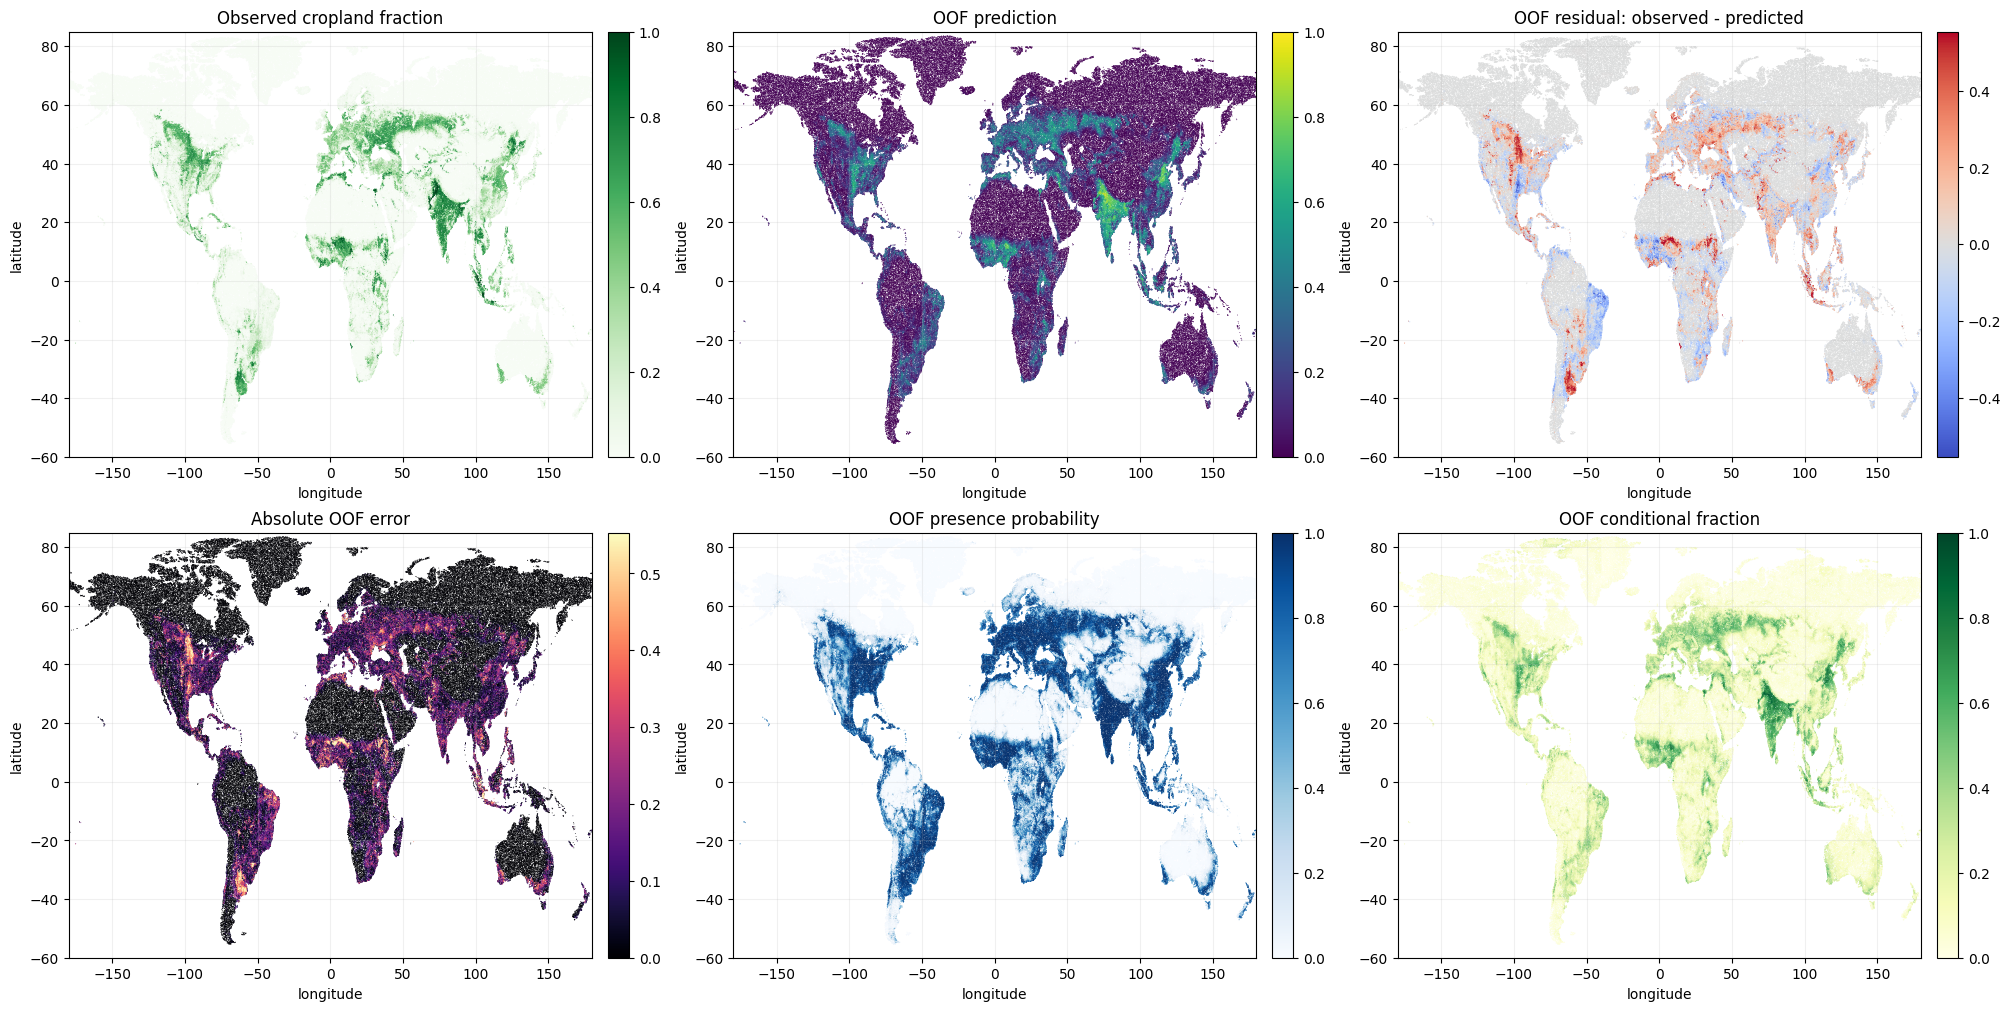

残差分布図: C:\masterresearch\Comparative_advantage\GAEZ\CroplandRegression\spatial_wx_comparison\no_population_raw_crop_wx_oof_shap\no_population_oof_residual_spatial_distribution.png


In [9]:
# ============================================================
# OOF残差の空間分布と残差 Moran's I
# ============================================================


def morans_i_knn(frame, residual, k=8, max_n=50_000, seed=RANDOM_SEED + 7000):
    residual = np.asarray(residual, dtype=float)
    coords = frame[["lat", "lon"]].to_numpy(dtype=float)
    valid = np.isfinite(residual) & np.isfinite(coords).all(axis=1)
    indices = np.flatnonzero(valid)
    if len(indices) > max_n:
        rng = np.random.default_rng(seed)
        indices = np.sort(rng.choice(indices, size=max_n, replace=False))
    selected_residual = residual[indices]
    selected_coords = coords[indices]
    tree = BallTree(np.radians(selected_coords), metric="haversine")
    _, neighbors = tree.query(np.radians(selected_coords), k=k + 1)
    neighbors = neighbors[:, 1:]
    centered = selected_residual - selected_residual.mean()
    denominator = float(np.sum(centered ** 2))
    neighbor_centered = centered[neighbors]
    numerator = float(np.sum(centered[:, None] * neighbor_centered) / neighbors.shape[1])
    moran = numerator / denominator if denominator > 0 else np.nan
    return {
        "morans_i": float(moran),
        "expected_i": float(-1.0 / (len(indices) - 1)),
        "n": int(len(indices)),
        "k": int(k),
        "mean_residual": float(selected_residual.mean()),
        "residual_sd": float(selected_residual.std()),
    }


no_pop_moran = pd.DataFrame([{
    "model": NO_POP_MODEL_NAME,
    **morans_i_knn(
        no_pop_oof_table,
        no_pop_oof_table["residual_observed_minus_predicted"].to_numpy(),
        k=MORAN_K,
        max_n=MORAN_MAX_N,
    ),
}])
no_pop_moran.to_csv(NO_POP_OUTPUT_DIR / "no_population_residual_morans_i.csv", index=False, encoding="utf-8-sig")
display(no_pop_moran.round(6))

plot_df = no_pop_oof_table
residual_vmax = float(np.nanpercentile(np.abs(plot_df["residual_observed_minus_predicted"]), 99.5))
residual_vmax = max(residual_vmax, 0.01)
absolute_vmax = max(float(np.nanpercentile(plot_df["absolute_error"], 99.5)), 0.01)

fig, axes = plt.subplots(2, 3, figsize=(20, 10), constrained_layout=True)
plots = [
    ("cropland_fraction", "Observed cropland fraction", "Greens", 0.0, 1.0),
    ("fraction_expected_oof", "OOF prediction", "viridis", 0.0, 1.0),
    ("residual_observed_minus_predicted", "OOF residual: observed - predicted", "coolwarm", -residual_vmax, residual_vmax),
    ("absolute_error", "Absolute OOF error", "magma", 0.0, absolute_vmax),
    ("presence_probability_calibrated", "OOF presence probability", "Blues", 0.0, 1.0),
    ("fraction_positive_conditional", "OOF conditional fraction", "YlGn", 0.0, 1.0),
]
for ax, (column, title, cmap, vmin, vmax) in zip(axes.ravel(), plots):
    values = plot_df[column].to_numpy(float)
    sc = ax.scatter(
        plot_df["lon"], plot_df["lat"], c=values, s=0.35,
        cmap=cmap, vmin=vmin, vmax=vmax, linewidths=0, rasterized=True,
    )
    ax.set_title(title)
    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")
    ax.set_xlim(-180, 180)
    ax.set_ylim(-60, 85)
    ax.grid(alpha=0.18)
    fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.03)

residual_figure = NO_POP_OUTPUT_DIR / "no_population_oof_residual_spatial_distribution.png"
fig.savefig(residual_figure, dpi=220, bbox_inches="tight")
plt.show()
print("残差分布図:", residual_figure)


## セル12：人口変数なしモデルのOOF SHAP

OOFの各テストfoldでLightGBMを再学習し、Stage 1とStage 2を分けてTree SHAPを計算する。

SHAPの合計は、Stage 1とStage 2を単純に足し合わせず、別々に解釈する。


## セル12：SHAPグループ定義

人口変数を除外したため、労働・人的資本グループは作らない。

- 気候・地理・自然資本
- 市場・インフラ資本
- 技術・投入資本
- データ有無フラグ（補助表示。生産要素としては解釈しない）


In [10]:
GROUP_ORDER = [
    "climate_geographic_natural_capital",
    "market_infrastructure_capital",
    "technology_input_capital",
    "data_availability",
]
MAIN_GROUPS = GROUP_ORDER[:-1]

GROUP_LABELS_JA = {
    "climate_geographic_natural_capital": "気候・地理・自然資本",
    "market_infrastructure_capital": "市場・インフラ資本",
    "technology_input_capital": "技術・投入資本",
    "data_availability": "データ利用可能性",
}


def capital_group(feature):
    feature = str(feature)
    if "exists" in feature or "missing" in feature or "exists_share" in feature:
        return "data_availability"
    base = feature.split("km_", 1)[1] if feature.startswith("wx_") else feature
    if "pop_density" in base:
        return "labor_human_capital"
    if "city_time" in base or "port_time" in base:
        return "market_infrastructure_capital"
    if "irrigation" in base:
        return "technology_input_capital"
    if (
        base in {"elevation_m", "slope", "exclusion_class"}
        or "glofas" in base
        or "distance_river" in base
        or "rainfed" in base
    ):
        return "climate_geographic_natural_capital"
    raise ValueError(f"Unclassified feature: {feature}")


GROUP_MAP = {feature: capital_group(feature) for feature in RAW_WX_SHAP_FEATURES}
GROUP_FEATURES = {
    group: [feature for feature in RAW_WX_SHAP_FEATURES if GROUP_MAP[feature] == group]
    for group in GROUP_ORDER
}
group_definition = pd.DataFrame([
    {
        "group": group,
        "label_ja": GROUP_LABELS_JA[group],
        "n_features": len(GROUP_FEATURES[group]),
        "features": "|".join(GROUP_FEATURES[group]),
    }
    for group in GROUP_ORDER
])
display(group_definition)

,group,label_ja,n_features,features
0,climate_geographic_natural_capital,気候・地理・自然資本,13,elevation_m|slope|exclusion_class|log_glofas_p...
1,market_infrastructure_capital,市場・インフラ資本,6,log_city_time_20k_min|log_port_time_any_min|wx...
2,technology_input_capital,技術・投入資本,4,irrigation_value_gain_top5_raw|irrigation_calo...
3,data_availability,データ利用可能性,10,rainfed_value_top5_exists|rainfed_calorie_top5...


## セル9：5-fold OOF SHAPを計算

In [11]:
individual_rows = []
group_rows = []
local_presence_frames = []
local_fraction_frames = []


def add_row(rows, stage, fold, key, n_features, features, values, indices):
    s = stats(values, indices)
    rows.append({
        "model": RAW_WX_SHAP_MODEL,
        "stage": stage,
        "fold": fold,
        "key": key,
        "n_features": n_features,
        "features": "|".join(features),
        **s,
    })


for fold_number, (train_idx, test_idx) in enumerate(splits, start=1):
    print("=" * 70)
    print(f"RAW_CROP_WX SHAP FOLD {fold_number}/{N_SPLITS}")
    train_df = raw_analysis_sample.iloc[train_idx].copy()
    classifier, regressor = fit_models(
        train_df, RAW_WX_SHAP_FEATURES, fold_number
    )

    cls_idx = choose_indices(
        test_idx, SHAP_MAX_ROWS_PER_FOLD,
        RANDOM_SEED + 3000 + fold_number,
    )
    cls_frame = raw_analysis_sample.iloc[cls_idx].copy()
    cls_values = tree_shap_raw(
        classifier, cls_frame, RAW_WX_SHAP_FEATURES
    )

    for j, feature in enumerate(RAW_WX_SHAP_FEATURES):
        add_row(
            individual_rows, "presence_classifier", fold_number,
            feature, 1, [feature], cls_values[:, j], cls_idx,
        )

    for group in GROUP_ORDER:
        group_features = GROUP_FEATURES[group]
        idx = [RAW_WX_SHAP_FEATURES.index(f) for f in group_features]
        signed = cls_values[:, idx].sum(axis=1)
        abs_total = np.abs(cls_values[:, idx]).sum(axis=1)
        add_row(
            group_rows, "presence_classifier", fold_number,
            group, len(group_features), group_features,
            abs_total, cls_idx,
        )
        group_rows[-1]["signed_num"] = stats(signed, cls_idx)["signed_num"]

    local_cls = cls_frame[
        ["row", "col", "lat", "lon", "spatial_block"]
    ].copy()
    local_cls["cv_fold"] = fold_number
    for j, feature in enumerate(RAW_WX_SHAP_FEATURES):
        local_cls[f"shap__{feature}"] = cls_values[:, j]
    local_presence_frames.append(local_cls)

    pos_idx = test_idx[y_all[test_idx] == 1]
    pos_idx = choose_indices(
        pos_idx, SHAP_MAX_ROWS_PER_FOLD,
        RANDOM_SEED + 4000 + fold_number,
    )

    if len(pos_idx) > 0:
        pos_frame = raw_analysis_sample.iloc[pos_idx].copy()
        reg_values = tree_shap_raw(
            regressor, pos_frame, RAW_WX_SHAP_FEATURES
        )

        for j, feature in enumerate(RAW_WX_SHAP_FEATURES):
            add_row(
                individual_rows, "conditional_fraction_regressor", fold_number,
                feature, 1, [feature], reg_values[:, j], pos_idx,
            )

        for group in GROUP_ORDER:
            group_features = GROUP_FEATURES[group]
            idx = [RAW_WX_SHAP_FEATURES.index(f) for f in group_features]
            signed = reg_values[:, idx].sum(axis=1)
            abs_total = np.abs(reg_values[:, idx]).sum(axis=1)
            add_row(
                group_rows, "conditional_fraction_regressor", fold_number,
                group, len(group_features), group_features,
                abs_total, pos_idx,
            )
            group_rows[-1]["signed_num"] = stats(signed, pos_idx)["signed_num"]

        local_reg = pos_frame[
            ["row", "col", "lat", "lon", "spatial_block"]
        ].copy()
        local_reg["cv_fold"] = fold_number
        for j, feature in enumerate(RAW_WX_SHAP_FEATURES):
            local_reg[f"shap__{feature}"] = reg_values[:, j]
        local_fraction_frames.append(local_reg)

    del classifier, regressor, cls_values
    if "reg_values" in locals():
        del reg_values
    gc.collect()

print("OOF SHAP calculation finished.")

RAW_CROP_WX SHAP FOLD 1/5


c:\Users\tsuda\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


RAW_CROP_WX SHAP FOLD 2/5


c:\Users\tsuda\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


RAW_CROP_WX SHAP FOLD 3/5


...

RAW_CROP_WX SHAP FOLD 4/5


c:\Users\tsuda\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


RAW_CROP_WX SHAP FOLD 5/5


c:\Users\tsuda\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


OOF SHAP calculation finished.


## セル10：個別・大分類SHAPの集計と保存

In [12]:
individual_fold = pd.DataFrame(individual_rows)
group_fold = pd.DataFrame(group_rows)


def finalize(frame, key_name):
    result = (
        frame.groupby(
            ["model", "stage", "key", "n_features", "features"],
            as_index=False,
        )[["n", "weight_sum", "abs_num", "signed_num"]]
        .sum()
    )
    result["mean_abs_shap"] = result["abs_num"] / result["weight_sum"].replace(0, np.nan)
    result["mean_signed_shap"] = result["signed_num"] / result["weight_sum"].replace(0, np.nan)
    result["mean_abs_shap_per_feature"] = result["mean_abs_shap"] / result["n_features"].replace(0, np.nan)
    result["relative_importance_share"] = (
        result.groupby(["model", "stage"])["mean_abs_shap"]
        .transform(lambda values: values / values.sum())
    )
    return result.rename(columns={"key": key_name})


individual_summary = finalize(individual_fold, "feature")
group_summary = finalize(group_fold, "group")

group_definition.to_csv(
    SHAP_OUTPUT_DIR / "capital_group_definition.csv",
    index=False, encoding="utf-8-sig"
)
individual_fold.to_csv(
    SHAP_OUTPUT_DIR / "raw_crop_wx_individual_shap_fold_statistics.csv",
    index=False, encoding="utf-8-sig"
)
group_fold.to_csv(
    SHAP_OUTPUT_DIR / "raw_crop_wx_capital_group_shap_fold_statistics.csv",
    index=False, encoding="utf-8-sig"
)
individual_summary.to_csv(
    SHAP_OUTPUT_DIR / "raw_crop_wx_individual_shap_summary.csv",
    index=False, encoding="utf-8-sig"
)
group_summary.to_csv(
    SHAP_OUTPUT_DIR / "raw_crop_wx_capital_group_shap_summary.csv",
    index=False, encoding="utf-8-sig"
)

local_presence = pd.concat(local_presence_frames, ignore_index=True)
local_fraction = pd.concat(local_fraction_frames, ignore_index=True)
local_presence.to_csv(
    SHAP_OUTPUT_DIR / "raw_crop_wx_presence_local_shap.csv.gz",
    index=False, compression="gzip"
)
local_fraction.to_csv(
    SHAP_OUTPUT_DIR / "raw_crop_wx_conditional_fraction_local_shap.csv.gz",
    index=False, compression="gzip"
)
print("saved:", SHAP_OUTPUT_DIR)

saved: C:\masterresearch\Comparative_advantage\GAEZ\CroplandRegression\spatial_wx_comparison\no_population_raw_crop_wx_oof_shap


## セル11：個別変数・大分類をplot.showで表示

C:\Users\tsuda\AppData\Local\Temp\ipykernel_27376\3735858149.py:27: UserWarning: Glyph 20154 (\N{CJK UNIFIED IDEOGRAPH-4EBA}) missing from font(s) DejaVu Sans.
  fig.savefig(path, dpi=220, bbox_inches="tight")
C:\Users\tsuda\AppData\Local\Temp\ipykernel_27376\3735858149.py:27: UserWarning: Glyph 21475 (\N{CJK UNIFIED IDEOGRAPH-53E3}) missing from font(s) DejaVu Sans.
  fig.savefig(path, dpi=220, bbox_inches="tight")
C:\Users\tsuda\AppData\Local\Temp\ipykernel_27376\3735858149.py:27: UserWarning: Glyph 22793 (\N{CJK UNIFIED IDEOGRAPH-5909}) missing from font(s) DejaVu Sans.
  fig.savefig(path, dpi=220, bbox_inches="tight")
C:\Users\tsuda\AppData\Local\Temp\ipykernel_27376\3735858149.py:27: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.savefig(path, dpi=220, bbox_inches="tight")
C:\Users\tsuda\AppData\Local\Temp\ipykernel_27376\3735858149.py:27: UserWarning: Glyph 12394 (\N{HIRAGANA LETTER NA}) missing from font(s) DejaVu Sans.
  fig.sa

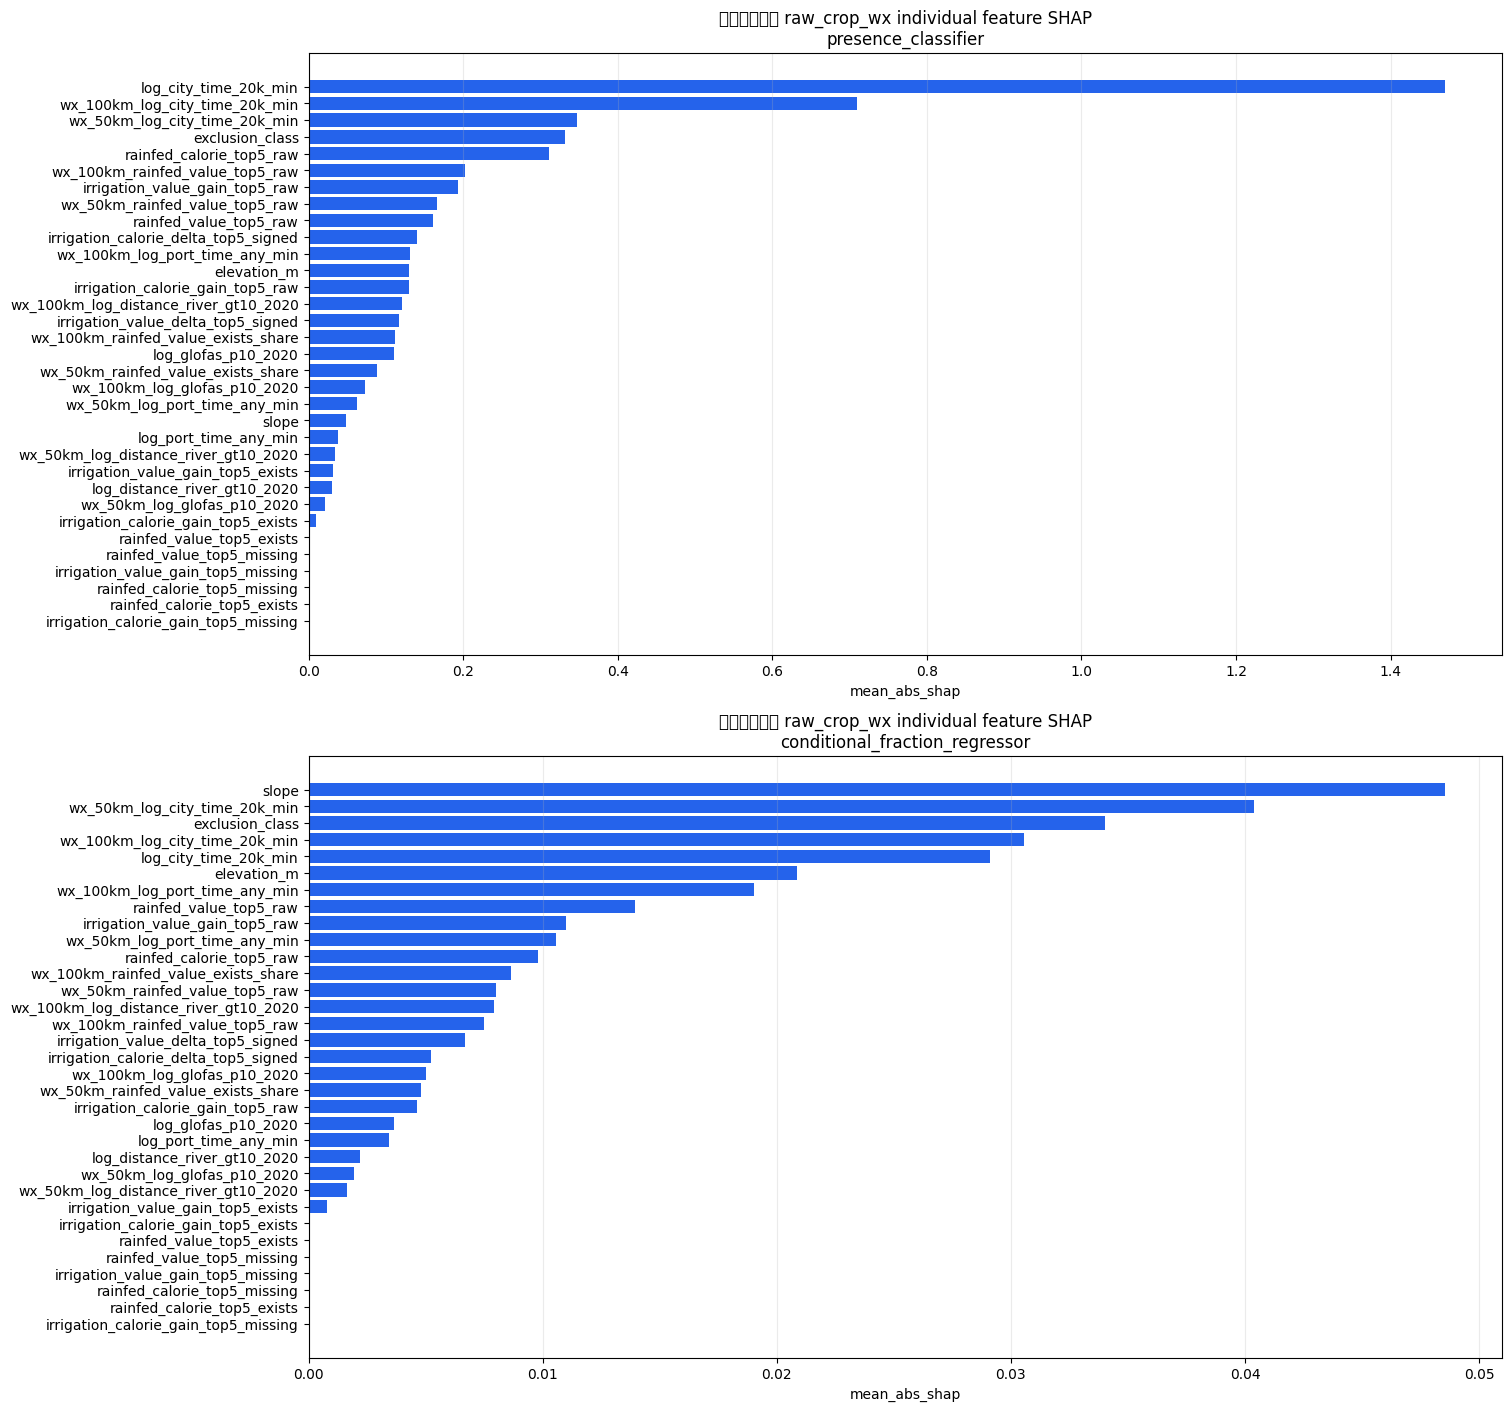

C:\Users\tsuda\AppData\Local\Temp\ipykernel_27376\3735858149.py:27: UserWarning: Glyph 20154 (\N{CJK UNIFIED IDEOGRAPH-4EBA}) missing from font(s) DejaVu Sans.
  fig.savefig(path, dpi=220, bbox_inches="tight")
C:\Users\tsuda\AppData\Local\Temp\ipykernel_27376\3735858149.py:27: UserWarning: Glyph 21475 (\N{CJK UNIFIED IDEOGRAPH-53E3}) missing from font(s) DejaVu Sans.
  fig.savefig(path, dpi=220, bbox_inches="tight")
C:\Users\tsuda\AppData\Local\Temp\ipykernel_27376\3735858149.py:27: UserWarning: Glyph 22793 (\N{CJK UNIFIED IDEOGRAPH-5909}) missing from font(s) DejaVu Sans.
  fig.savefig(path, dpi=220, bbox_inches="tight")
C:\Users\tsuda\AppData\Local\Temp\ipykernel_27376\3735858149.py:27: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.savefig(path, dpi=220, bbox_inches="tight")
C:\Users\tsuda\AppData\Local\Temp\ipykernel_27376\3735858149.py:27: UserWarning: Glyph 12394 (\N{HIRAGANA LETTER NA}) missing from font(s) DejaVu Sans.
  fig.sa

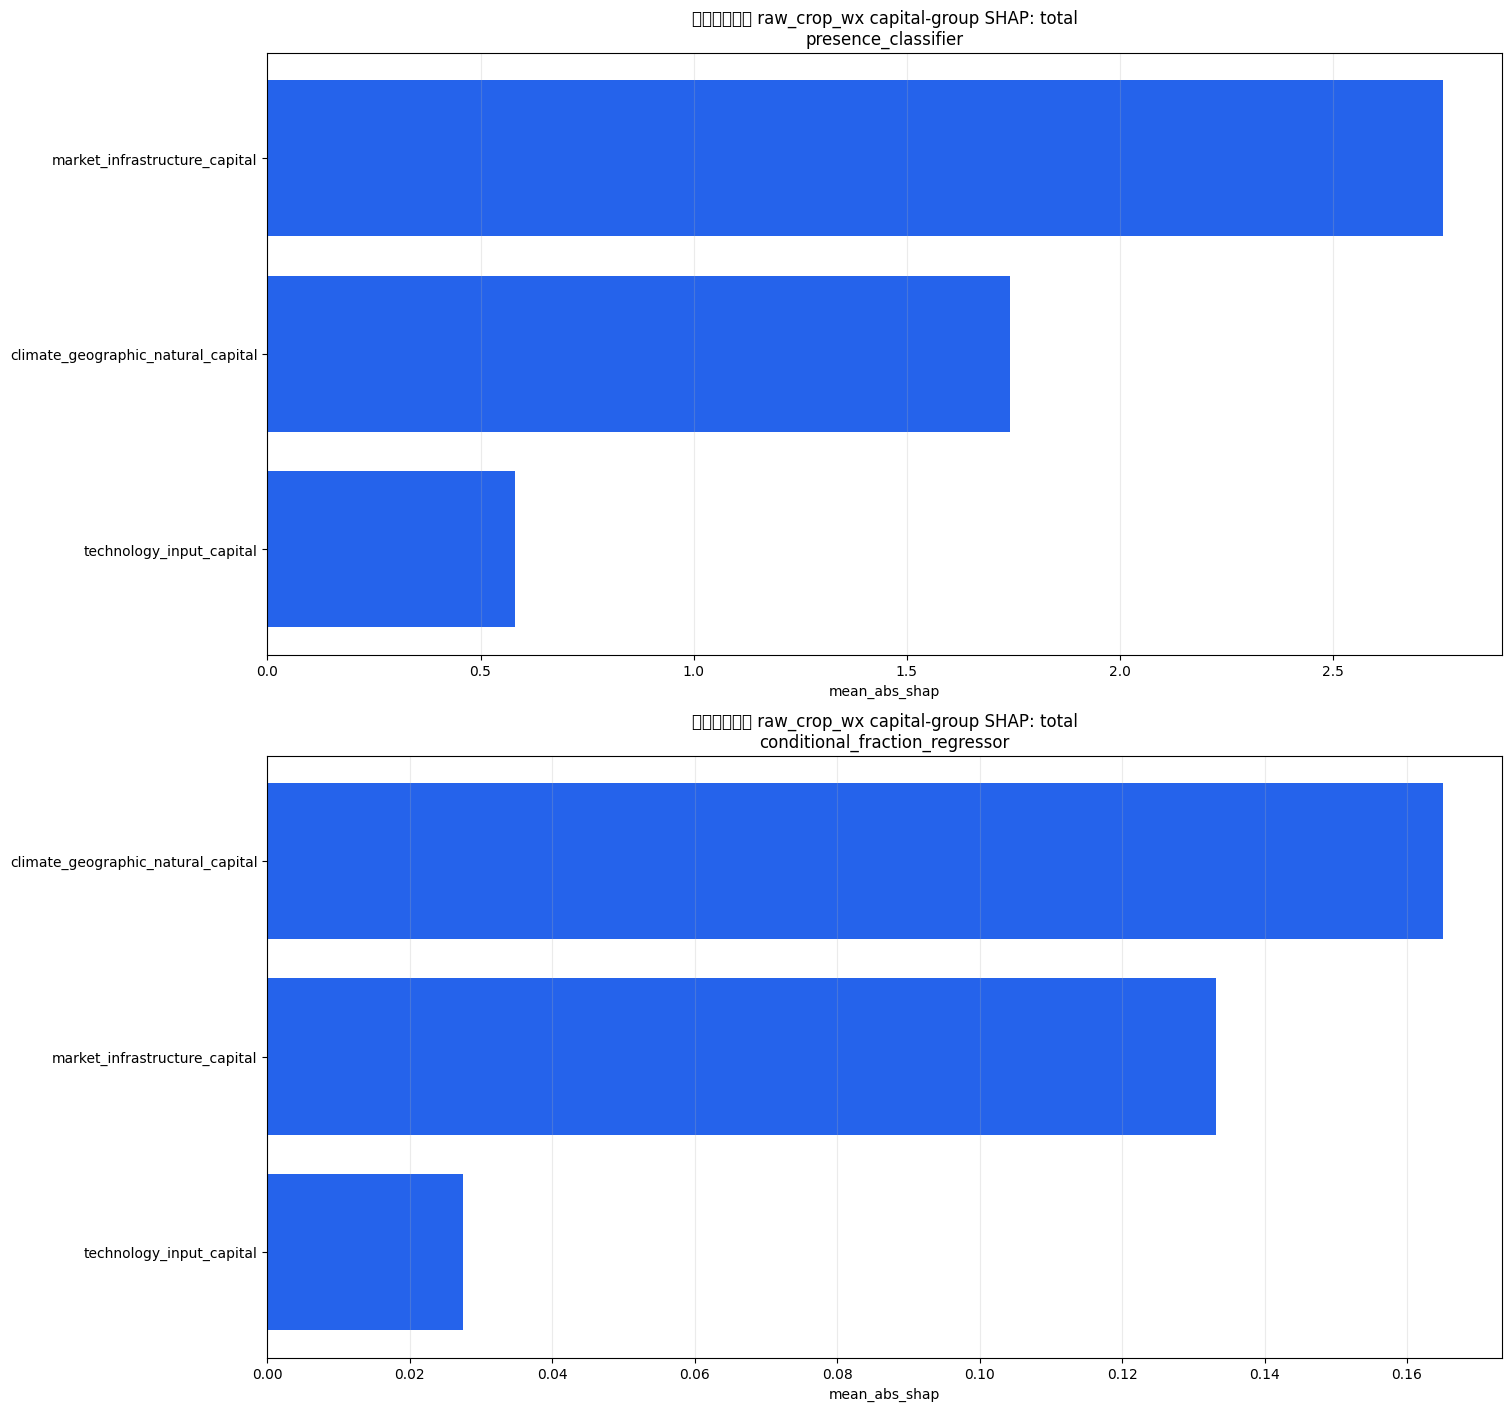

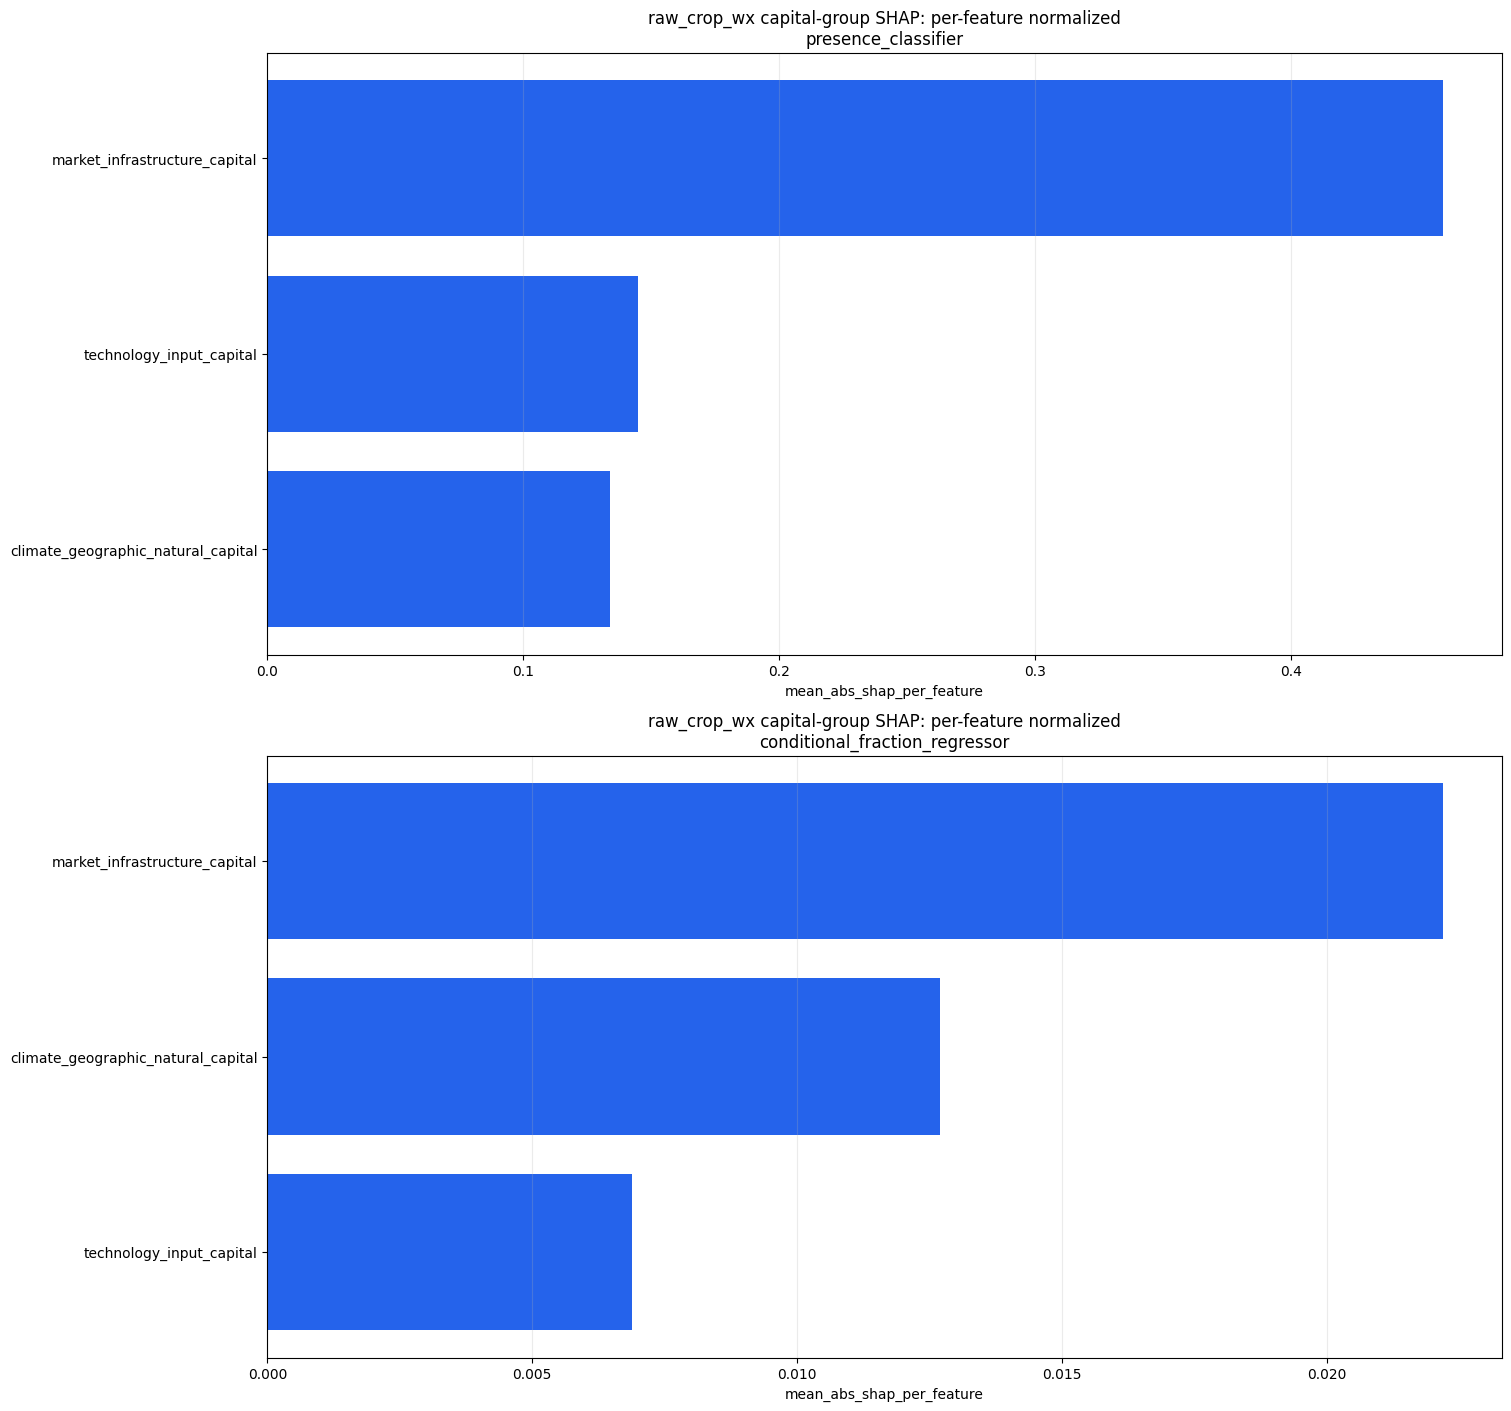

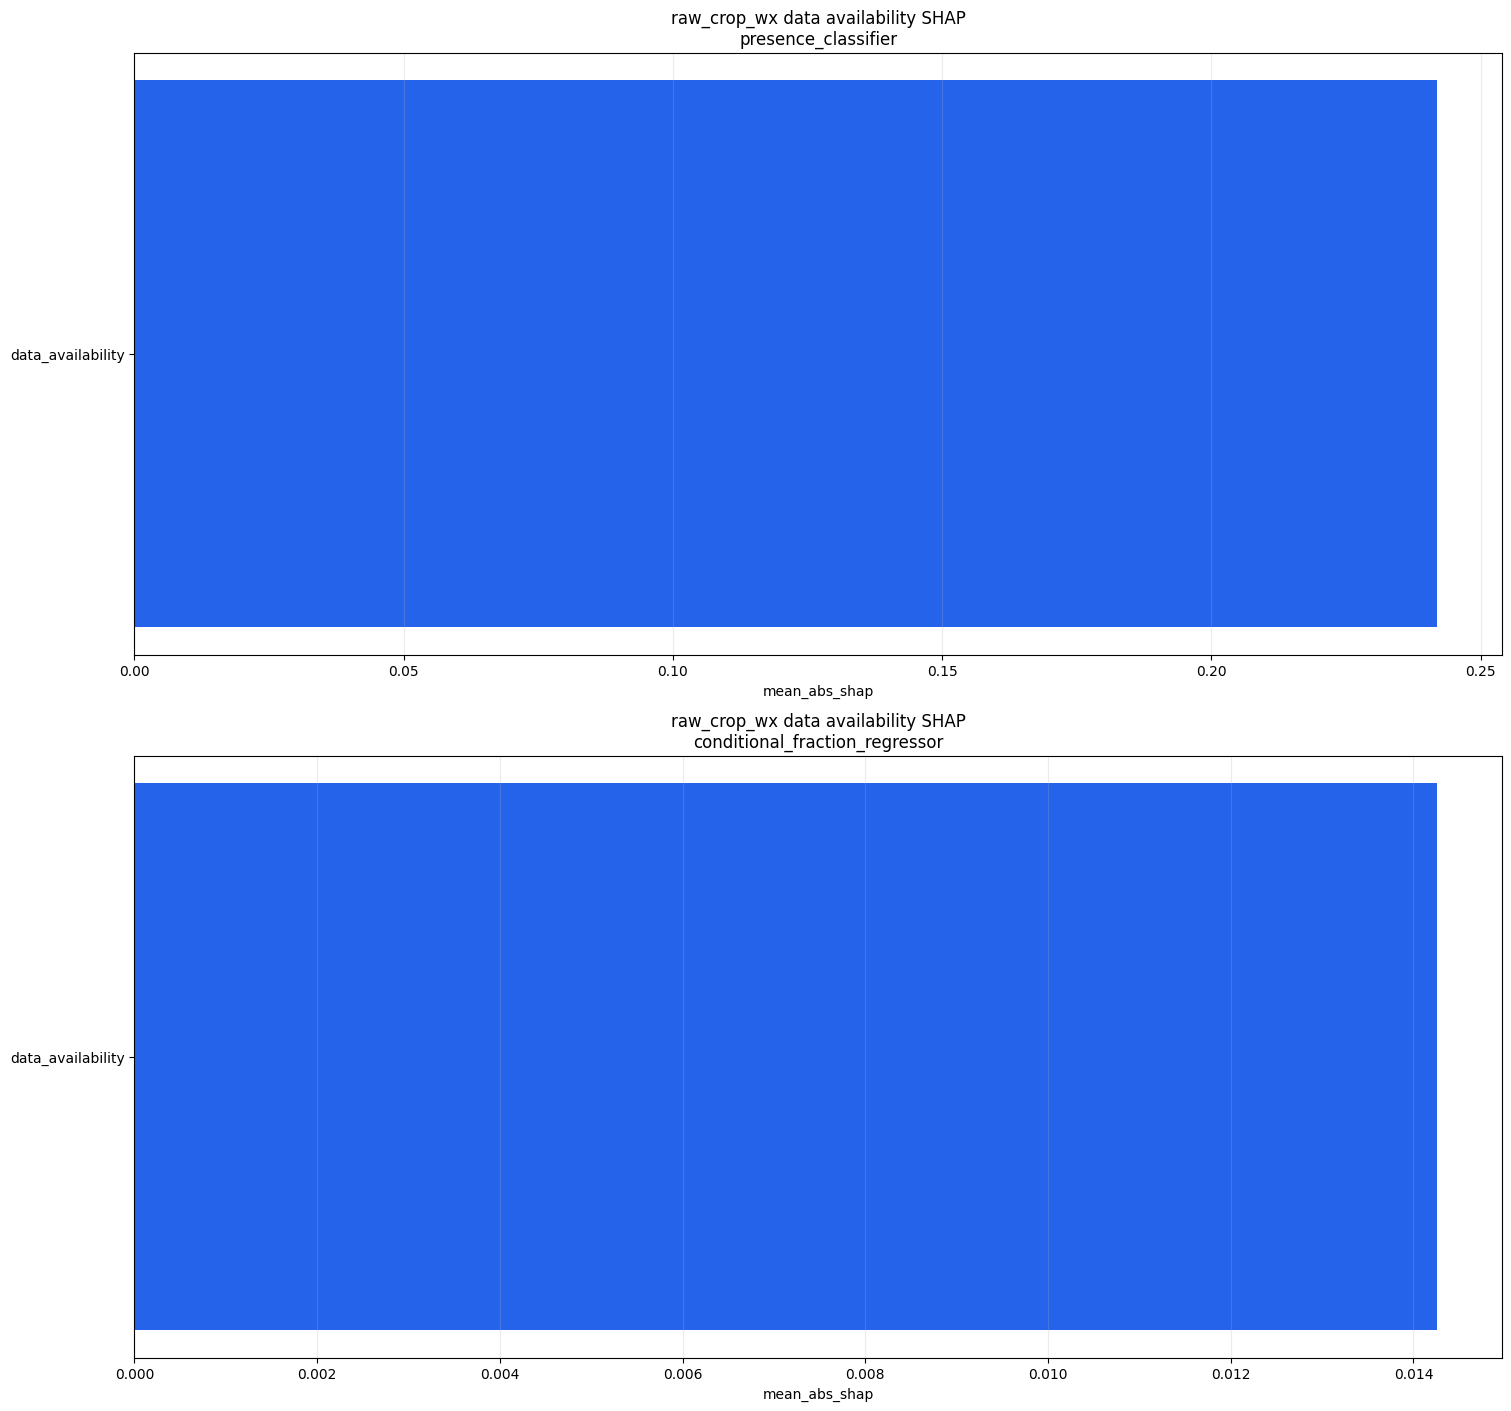

In [13]:
def plot_summary(frame, key, title, filename, value_column, selected=None):
    plot_frame = frame.copy()
    if selected is not None:
        plot_frame = plot_frame[plot_frame[key].isin(selected)].copy()

    stages = ["presence_classifier", "conditional_fraction_regressor"]
    fig, axes = plt.subplots(
        len(stages), 1, figsize=(15, 7 * len(stages)),
        squeeze=False, constrained_layout=True
    )

    for row_index, stage in enumerate(stages):
        stage_frame = plot_frame[
            plot_frame["stage"] == stage
        ].sort_values(value_column, ascending=True)
        ax = axes[row_index, 0]
        ax.barh(
            stage_frame[key].astype(str),
            stage_frame[value_column],
            color="#2563eb",
        )
        ax.set_title(f"{title}\n{stage}")
        ax.set_xlabel(value_column)
        ax.grid(axis="x", alpha=0.25)

    path = SHAP_OUTPUT_DIR / filename
    fig.savefig(path, dpi=220, bbox_inches="tight")
    plt.show()
    return path


individual_figure = plot_summary(
    individual_summary, "feature",
    "人口変数なし raw_crop_wx individual feature SHAP",
    "raw_crop_wx_individual_shap.png",
    "mean_abs_shap",
)
group_total_figure = plot_summary(
    group_summary, "group",
    "人口変数なし raw_crop_wx capital-group SHAP: total",
    "raw_crop_wx_capital_group_shap_total.png",
    "mean_abs_shap", MAIN_GROUPS,
)
group_per_feature_figure = plot_summary(
    group_summary, "group",
    "raw_crop_wx capital-group SHAP: per-feature normalized",
    "raw_crop_wx_capital_group_shap_per_feature.png",
    "mean_abs_shap_per_feature", MAIN_GROUPS,
)
data_figure = plot_summary(
    group_summary, "group",
    "raw_crop_wx data availability SHAP",
    "raw_crop_wx_data_availability_shap.png",
    "mean_abs_shap", ["data_availability"],
)

In [14]:
print("=" * 80)
print("INDIVIDUAL FEATURE SHAP")
print("=" * 80)
display(
    individual_summary[
        ["stage", "feature", "mean_abs_shap",
         "mean_signed_shap", "relative_importance_share"]
    ].round(6)
)

print("=" * 80)
print("CAPITAL-GROUP SHAP")
print("=" * 80)
display(
    group_summary[
        ["stage", "group", "n_features",
         "mean_abs_shap", "mean_abs_shap_per_feature",
         "mean_signed_shap", "relative_importance_share"]
    ].round(6)
)

print("保存先:", SHAP_OUTPUT_DIR)
print("個別変数図:", individual_figure)
print("大分類・合計図:", group_total_figure)
print("大分類・変数数補正図:", group_per_feature_figure)
print("data availability図:", data_figure)

INDIVIDUAL FEATURE SHAP


,stage,feature,mean_abs_shap,mean_signed_shap,relative_importance_share
0,conditional_fraction_regressor,elevation_m,0.020885,-0.003440,0.061443
1,conditional_fraction_regressor,exclusion_class,0.034035,0.000694,0.100131
2,conditional_fraction_regressor,irrigation_calorie_delta_top5_signed,0.005211,-0.000366,0.015332
3,conditional_fraction_regressor,irrigation_calorie_gain_top5_exists,0.000052,-0.000005,0.000152
4,conditional_fraction_regressor,irrigation_calorie_gain_top5_missing,0.000000,0.000000,0.000000
...,...,...,...,...,...
61,presence_classifier,wx_50km_log_distance_river_gt10_2020,0.033943,-0.009682,0.006380
62,presence_classifier,wx_50km_log_glofas_p10_2020,0.021559,0.002861,0.004052
63,presence_classifier,wx_50km_log_port_time_any_min,0.062039,0.001281,0.011661
64,presence_classifier,wx_50km_rainfed_value_exists_share,0.088424,-0.016170,0.016620


CAPITAL-GROUP SHAP


,stage,group,n_features,mean_abs_shap,mean_abs_shap_per_feature,mean_signed_shap,relative_importance_share
0,conditional_fraction_regressor,climate_geographic_natural_capital,13,0.165032,0.012695,-0.009577,0.485517
1,conditional_fraction_regressor,data_availability,10,0.014253,0.001425,-0.000285,0.041933
2,conditional_fraction_regressor,market_infrastructure_capital,6,0.133119,0.022186,-0.004050,0.391631
3,conditional_fraction_regressor,technology_input_capital,4,0.027505,0.006876,0.001008,0.080919
4,presence_classifier,climate_geographic_natural_capital,13,1.741617,0.133971,-0.141127,0.327349
5,presence_classifier,data_availability,10,0.241808,0.024181,-0.016348,0.045450
6,presence_classifier,market_infrastructure_capital,6,2.757173,0.459529,0.077974,0.518230
7,presence_classifier,technology_input_capital,4,0.579771,0.144943,0.024366,0.108972


保存先: C:\masterresearch\Comparative_advantage\GAEZ\CroplandRegression\spatial_wx_comparison\no_population_raw_crop_wx_oof_shap
個別変数図: C:\masterresearch\Comparative_advantage\GAEZ\CroplandRegression\spatial_wx_comparison\no_population_raw_crop_wx_oof_shap\raw_crop_wx_individual_shap.png
大分類・合計図: C:\masterresearch\Comparative_advantage\GAEZ\CroplandRegression\spatial_wx_comparison\no_population_raw_crop_wx_oof_shap\raw_crop_wx_capital_group_shap_total.png
大分類・変数数補正図: C:\masterresearch\Comparative_advantage\GAEZ\CroplandRegression\spatial_wx_comparison\no_population_raw_crop_wx_oof_shap\raw_crop_wx_capital_group_shap_per_feature.png
data availability図: C:\masterresearch\Comparative_advantage\GAEZ\CroplandRegression\spatial_wx_comparison\no_population_raw_crop_wx_oof_shap\raw_crop_wx_data_availability_shap.png


## セル12：読み方

mean_abs_shapはグループ全体へのモデル依存度で、変数数が多いグループほど大きくなりやすい。
そのため、mean_abs_shap_per_featureも併記する。

mean_signed_shapは、グループが予測を押し上げる方向か押し下げる方向かを見る指標である。
data_availabilityは生産要素ではないので、農業レジームの解釈には直接使わない。

このノートブックのLightGBMは1本のpooledモデルであり、レジーム別モデルではない。
保存したセル別OOF SHAPは、次の段階で生産要素への反応プロファイルを分析するために使える。

## 13 各変数ローカルshapの可視化

In [15]:
# ============================================================
# Local SHAP spatial maps
# Slide-friendly layout with horizontal colorbars
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. 表示グループ
# ============================================================

MAP_GROUPS = {
    "Terrain and land constraints": [
        "elevation_m",
        "slope",
        "exclusion_class",
    ],

    "Climate and water resources": [
        "log_glofas_p10_2020",
        "wx_50km_log_glofas_p10_2020",
        "wx_100km_log_glofas_p10_2020",
        "log_distance_river_gt10_2020",
        "wx_50km_log_distance_river_gt10_2020",
        "wx_100km_log_distance_river_gt10_2020",
    ],

    "Market access": [
        "log_city_time_20k_min",
        "wx_50km_log_city_time_20k_min",
        "wx_100km_log_city_time_20k_min",
        "log_port_time_any_min",
        "wx_50km_log_port_time_any_min",
        "wx_100km_log_port_time_any_min",
    ],

    "Rainfed crop potential": [
        "rainfed_value_top5_raw",
        "rainfed_calorie_top5_raw",
        "wx_50km_rainfed_value_top5_raw",
        "wx_100km_rainfed_value_top5_raw",
        "wx_50km_rainfed_value_exists_share",
        "wx_100km_rainfed_value_exists_share",
    ],

    "Irrigation biophysical potential": [
        "irrigation_value_gain_top5_raw",
        "irrigation_calorie_gain_top5_raw",
        "irrigation_value_delta_top5_signed",
        "irrigation_calorie_delta_top5_signed",
    ],

    "Data availability indicators": [
        "rainfed_value_top5_exists",
        "rainfed_calorie_top5_exists",
        "irrigation_value_gain_top5_exists",
        "irrigation_calorie_gain_top5_exists",
        "rainfed_value_top5_missing",
        "rainfed_calorie_top5_missing",
        "irrigation_value_gain_top5_missing",
        "irrigation_calorie_gain_top5_missing",
    ],
}


FEATURES_PER_SHEET = 4
GLOBAL_COLOR_QUANTILE = 0.99


# ============================================================
# 2. データ確認
# ============================================================

# presence_df / conditional_df がメモリ上になければ、保存済みOOF SHAPを読み込む
# これにより、このセルを単独で実行できる
from pathlib import Path

if "SHAP_OUTPUT_DIR" not in globals():
    SHAP_OUTPUT_DIR = Path(
        r"C:\masterresearch\Comparative_advantage\GAEZ\CroplandRegression\spatial_wx_comparison\no_population_raw_crop_wx_oof_shap"
    )

if "presence_df" not in globals():
    if "local_presence" in globals():
        presence_df = local_presence.copy()
    else:
        _presence_shap_path = (
            SHAP_OUTPUT_DIR
            / "raw_crop_wx_presence_local_shap.csv.gz"
        )
        if not _presence_shap_path.exists():
            raise FileNotFoundError(
                f"存在確率SHAPファイルがありません: {_presence_shap_path}"
            )
        presence_df = pd.read_csv(
            _presence_shap_path,
            compression="gzip",
        )

if "conditional_df" not in globals():
    if "local_fraction" in globals():
        conditional_df = local_fraction.copy()
    else:
        _conditional_shap_path = (
            SHAP_OUTPUT_DIR
            / "raw_crop_wx_conditional_fraction_local_shap.csv.gz"
        )
        if not _conditional_shap_path.exists():
            raise FileNotFoundError(
                f"条件付き割合SHAPファイルがありません: {_conditional_shap_path}"
            )
        conditional_df = pd.read_csv(
            _conditional_shap_path,
            compression="gzip",
        )


# ============================================================
# 3. 利用可能なSHAP変数
# ============================================================

def get_shap_features(df):
    return {
        col.replace("shap__", "", 1)
        for col in df.columns
        if col.startswith("shap__")
    }


presence_available = get_shap_features(
    presence_df
)

conditional_available = get_shap_features(
    conditional_df
)

available_features = (
    presence_available
    & conditional_available
)


GLOBAL_FEATURES = [
    feature
    for group_features in MAP_GROUPS.values()
    for feature in group_features
    if feature in available_features
]

print(
    "利用可能なSHAP変数数:",
    len(GLOBAL_FEATURES)
)


# ============================================================
# 4. 全シート共通のカラーバー範囲
# ============================================================

def calculate_global_shap_limit(
    df,
    features,
    quantile=0.99,
):
    absolute_values = []

    for feature in features:
        shap_col = f"shap__{feature}"

        if shap_col not in df.columns:
            continue

        values = pd.to_numeric(
            df[shap_col],
            errors="coerce",
        ).to_numpy(dtype=float)

        values = values[
            np.isfinite(values)
        ]

        if len(values) > 0:
            absolute_values.append(
                np.abs(values)
            )

    if len(absolute_values) == 0:
        return 1.0

    absolute_values = np.concatenate(
        absolute_values
    )

    limit = np.quantile(
        absolute_values,
        quantile,
    )

    if not np.isfinite(limit) or limit == 0:
        limit = np.max(absolute_values)

    if not np.isfinite(limit) or limit == 0:
        limit = 1.0

    return float(limit)


PRESENCE_GLOBAL_LIMIT = calculate_global_shap_limit(
    df=presence_df,
    features=GLOBAL_FEATURES,
    quantile=GLOBAL_COLOR_QUANTILE,
)

CONDITIONAL_GLOBAL_LIMIT = calculate_global_shap_limit(
    df=conditional_df,
    features=GLOBAL_FEATURES,
    quantile=GLOBAL_COLOR_QUANTILE,
)

print(
    "Presence classifier:",
    f"-{PRESENCE_GLOBAL_LIMIT:.4f}",
    "to",
    f"+{PRESENCE_GLOBAL_LIMIT:.4f}",
)

print(
    "Conditional fraction:",
    f"-{CONDITIONAL_GLOBAL_LIMIT:.4f}",
    "to",
    f"+{CONDITIONAL_GLOBAL_LIMIT:.4f}",
)


# ============================================================
# 5. 空間データ準備
# ============================================================

def prepare_spatial_data(
    df,
    feature,
):
    shap_col = f"shap__{feature}"

    required_cols = [
        "lat",
        "lon",
        shap_col,
    ]

    if any(
        col not in df.columns
        for col in required_cols
    ):
        return None

    result = df[
        required_cols
    ].copy()

    for col in required_cols:
        result[col] = pd.to_numeric(
            result[col],
            errors="coerce",
        )

    result = result.replace(
        [np.inf, -np.inf],
        np.nan,
    ).dropna()

    return result


# ============================================================
# 6. 地図を描く
# ============================================================

def draw_spatial_shap_map(
    ax,
    df,
    feature,
    stage_title,
    global_limit,
):
    spatial_df = prepare_spatial_data(
        df=df,
        feature=feature,
    )

    if spatial_df is None or len(spatial_df) == 0:
        ax.set_title(
            f"{feature}\n{stage_title}\n(no data)"
        )
        ax.axis("off")
        return None

    shap_col = f"shap__{feature}"

    scatter = ax.scatter(
        spatial_df["lon"],
        spatial_df["lat"],
        c=spatial_df[shap_col],
        cmap="coolwarm",
        vmin=-global_limit,
        vmax=global_limit,
        s=1.2,
        linewidths=0,
        alpha=0.75,
        rasterized=True,
    )

    ax.set_xlim(-180, 180)
    ax.set_ylim(-60, 85)

    # 世界地図として縦横比を整える
    ax.set_box_aspect(
        (85 - (-60)) / (180 - (-180))
    )

    ax.set_title(
        f"{feature}\n{stage_title}",
        fontsize=10,
        pad=5,
    )

    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")

    ax.grid(
        alpha=0.20,
        linewidth=0.5,
    )

    return scatter


# ============================================================
# 7. シートを作成
# ============================================================

def plot_grouped_spatial_shap_sheets(
    group_name,
    features,
    sheet_number_start,
):
    valid_features = [
        feature
        for feature in features
        if feature in available_features
    ]

    if len(valid_features) == 0:
        print(
            f"{group_name}: 利用可能な変数がありません"
        )
        return sheet_number_start

    sheet_number = sheet_number_start

    for start in range(
        0,
        len(valid_features),
        FEATURES_PER_SHEET,
    ):
        sheet_features = valid_features[
            start:
            start + FEATURES_PER_SHEET
        ]

        n_rows = len(sheet_features)

        # ----------------------------------------------------
        # 行：
        #   左  = Presence classifier
        #   右  = Conditional fraction regressor
        #
        # 最下段：
        #   左  = Presence用カラーバー
        #   右  = Conditional用カラーバー
        # ----------------------------------------------------

        fig = plt.figure(
            figsize=(
                20,
                4.3 * n_rows + 1.4,
            )
        )

        grid = fig.add_gridspec(
            nrows=n_rows + 1,
            ncols=2,
            height_ratios=(
                [1.0] * n_rows
                + [0.10]
            ),
            width_ratios=[1.0, 1.0],
            hspace=0.32,
            wspace=0.08,
        )

        presence_axes = []
        conditional_axes = []

        for row_index in range(n_rows):
            presence_axes.append(
                fig.add_subplot(
                    grid[row_index, 0]
                )
            )

            conditional_axes.append(
                fig.add_subplot(
                    grid[row_index, 1]
                )
            )

        # カラーバー専用の横長軸
        presence_cax = fig.add_subplot(
            grid[n_rows, 0]
        )

        conditional_cax = fig.add_subplot(
            grid[n_rows, 1]
        )

        presence_mappable = None
        conditional_mappable = None

        for row_index, feature in enumerate(
            sheet_features
        ):
            presence_mappable = (
                draw_spatial_shap_map(
                    ax=presence_axes[row_index],
                    df=presence_df,
                    feature=feature,
                    stage_title="Presence classifier",
                    global_limit=PRESENCE_GLOBAL_LIMIT,
                )
            )

            conditional_mappable = (
                draw_spatial_shap_map(
                    ax=conditional_axes[row_index],
                    df=conditional_df,
                    feature=feature,
                    stage_title="Conditional fraction regressor",
                    global_limit=CONDITIONAL_GLOBAL_LIMIT,
                )
            )

        # ----------------------------------------------------
        # 横向きカラーバー
        # ----------------------------------------------------

        if presence_mappable is not None:
            presence_cbar = fig.colorbar(
                presence_mappable,
                cax=presence_cax,
                orientation="horizontal",
            )

            presence_cbar.set_label(
                "local SHAP — presence classifier",
                fontsize=9,
                labelpad=3,
            )

            presence_cbar.ax.tick_params(
                labelsize=8
            )

        else:
            presence_cax.axis("off")

        if conditional_mappable is not None:
            conditional_cbar = fig.colorbar(
                conditional_mappable,
                cax=conditional_cax,
                orientation="horizontal",
            )

            conditional_cbar.set_label(
                "local SHAP — conditional fraction regressor",
                fontsize=9,
                labelpad=3,
            )

            conditional_cbar.ax.tick_params(
                labelsize=8
            )

        else:
            conditional_cax.axis("off")

        fig.suptitle(
            f"Spatial distribution of local SHAP\n"
            f"{group_name} "
            f"(Sheet {sheet_number})",
            fontsize=18,
            y=0.995,
        )

        fig.text(
            0.5,
            0.005,
            "Color scales are globally fixed across all sheets "
            "within each model stage",
            ha="center",
            fontsize=9,
        )

        # 図全体の余白を調整
        fig.subplots_adjust(
            left=0.04,
            right=0.96,
            top=0.94,
            bottom=0.07,
        )

        plt.show()

        sheet_number += 1

    return sheet_number


# ============================================================
# 8. 全グループを描画
# ============================================================

current_sheet_number = 1

for group_name, features in MAP_GROUPS.items():
    print("=" * 80)
    print(group_name)
    print("=" * 80)

    current_sheet_number = (
        plot_grouped_spatial_shap_sheets(
            group_name=group_name,
            features=features,
            sheet_number_start=current_sheet_number,
        )
    )

print("全シートの描画が完了しました。")

RuntimeError: presence_df がありません。SHAP読み込みセルを先に実行してください。

## 14 shapと説明変数の関係

In [ ]:
# ============================================================
# 説明変数の値とOOF SHAP値の関係を可視化
# 人口変数なし・raw_crop_wxモデル対応版
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


# ============================================================
# 1. 設定
# ============================================================

SHAP_OUTPUT_DIR = Path(
    r"C:\masterresearch\Comparative_advantage\GAEZ"
    r"\CroplandRegression\spatial_wx_comparison"
    r"\no_population_raw_crop_wx_oof_shap"
)

PRESENCE_SHAP_FILE = (
    SHAP_OUTPUT_DIR
    / "raw_crop_wx_presence_local_shap.csv.gz"
)

CONDITIONAL_SHAP_FILE = (
    SHAP_OUTPUT_DIR
    / "raw_crop_wx_conditional_fraction_local_shap.csv.gz"
)

# 全変数を描画する場合
PLOT_FEATURES = None

# 上位変数だけ見たい場合は、例えば以下のように変更
# PLOT_FEATURES = [
#     "elevation_m",
#     "slope",
#     "exclusion_class",
#     "log_city_time_20k_min",
#     "rainfed_value_top5_raw",
# ]

N_COLS = 3
N_ROWS = 4
N_BINS = 20
RANDOM_SEED = 1234


# ============================================================
# 2. 人口なしモデルの説明変数
# ============================================================

NO_POP_FEATURES_REQUESTED = [
    "elevation_m",
    "slope",
    "exclusion_class",

    "log_city_time_20k_min",
    "log_port_time_any_min",
    "log_glofas_p10_2020",
    "log_distance_river_gt10_2020",

    "rainfed_value_top5_raw",
    "rainfed_calorie_top5_raw",
    "irrigation_value_gain_top5_raw",
    "irrigation_calorie_gain_top5_raw",

    "rainfed_value_top5_exists",
    "rainfed_calorie_top5_exists",
    "irrigation_value_gain_top5_exists",
    "irrigation_calorie_gain_top5_exists",

    "irrigation_value_delta_top5_signed",
    "irrigation_calorie_delta_top5_signed",

    "rainfed_value_top5_missing",
    "rainfed_calorie_top5_missing",
    "irrigation_value_gain_top5_missing",
    "irrigation_calorie_gain_top5_missing",

    "wx_50km_log_city_time_20k_min",
    "wx_50km_log_port_time_any_min",
    "wx_50km_log_glofas_p10_2020",
    "wx_50km_log_distance_river_gt10_2020",

    "wx_100km_log_city_time_20k_min",
    "wx_100km_log_port_time_any_min",
    "wx_100km_log_glofas_p10_2020",
    "wx_100km_log_distance_river_gt10_2020",

    "wx_50km_rainfed_value_top5_raw",
    "wx_50km_rainfed_value_exists_share",
    "wx_100km_rainfed_value_top5_raw",
    "wx_100km_rainfed_value_exists_share",
]


# ============================================================
# 3. 必要な元データの確認
# ============================================================

if "raw_analysis_sample" not in globals():
    raise RuntimeError(
        "raw_analysis_sample がありません。"
        "元のモデル構築セルを先に実行してください。"
    )

if not PRESENCE_SHAP_FILE.exists():
    raise FileNotFoundError(
        f"存在確率モデルのSHAPファイルがありません:\n"
        f"{PRESENCE_SHAP_FILE}"
    )

if not CONDITIONAL_SHAP_FILE.exists():
    raise FileNotFoundError(
        f"条件付き割合モデルのSHAPファイルがありません:\n"
        f"{CONDITIONAL_SHAP_FILE}"
    )


# ============================================================
# 4. SHAPファイルの読み込み
# ============================================================

presence_shap = pd.read_csv(
    PRESENCE_SHAP_FILE,
    compression="gzip"
)

conditional_shap = pd.read_csv(
    CONDITIONAL_SHAP_FILE,
    compression="gzip"
)


# ============================================================
# 5. 実際にSHAPファイルに存在する変数だけを採用
# ============================================================

def get_shap_feature_names(df):
    prefix = "shap__"

    return {
        col[len(prefix):]
        for col in df.columns
        if col.startswith(prefix)
    }


presence_shap_features = get_shap_feature_names(
    presence_shap
)

conditional_shap_features = get_shap_feature_names(
    conditional_shap
)

raw_data_features = set(
    raw_analysis_sample.columns
)

# 両方の段階にSHAPが存在し、
# 元データにも存在する変数のみを採用
AVAILABLE_FEATURES = [
    feature
    for feature in NO_POP_FEATURES_REQUESTED
    if (
        feature in presence_shap_features
        and feature in conditional_shap_features
        and feature in raw_data_features
    )
]

EXCLUDED_FEATURES = [
    feature
    for feature in NO_POP_FEATURES_REQUESTED
    if feature not in AVAILABLE_FEATURES
]

if PLOT_FEATURES is None:
    PLOT_FEATURES = AVAILABLE_FEATURES.copy()
else:
    PLOT_FEATURES = [
        feature
        for feature in PLOT_FEATURES
        if feature in AVAILABLE_FEATURES
    ]

print("描画対象の変数数:", len(PLOT_FEATURES))
print("描画対象の変数:")
print(PLOT_FEATURES)

print("\n除外された変数:")
print(EXCLUDED_FEATURES)


# ============================================================
# 6. 説明変数値とSHAP値を結合
# ============================================================

KEY_COLS = ["row", "col"]

feature_value_cols = [
    col
    for col in PLOT_FEATURES
    if col in raw_analysis_sample.columns
]

feature_values = raw_analysis_sample[
    KEY_COLS + feature_value_cols
].copy()

for col in KEY_COLS:
    feature_values[col] = pd.to_numeric(
        feature_values[col],
        errors="coerce"
    ).astype("Int64")


def prepare_shap_dataframe(shap_df):
    """
    SHAP値と説明変数値をrow・colで結合する。
    """

    shap_df = shap_df.copy()

    for col in KEY_COLS:
        shap_df[col] = pd.to_numeric(
            shap_df[col],
            errors="coerce"
        ).astype("Int64")

    shap_cols = [
        f"shap__{feature}"
        for feature in PLOT_FEATURES
        if f"shap__{feature}" in shap_df.columns
    ]

    metadata_cols = [
        col
        for col in [
            "lat",
            "lon",
            "spatial_block",
            "cv_fold",
        ]
        if col in shap_df.columns
    ]

    result = shap_df[
        KEY_COLS + metadata_cols + shap_cols
    ].merge(
        feature_values,
        on=KEY_COLS,
        how="left",
        validate="many_to_one",
    )

    return result


presence_df = prepare_shap_dataframe(
    presence_shap
)

conditional_df = prepare_shap_dataframe(
    conditional_shap
)

print("\n存在確率モデルの行数:", len(presence_df))
print("条件付き割合モデルの行数:", len(conditional_df))


# ============================================================
# 7. 数値要約
# ============================================================

def calculate_relation_summary(
    df,
    stage_name,
):
    rows = []

    for feature in PLOT_FEATURES:
        shap_col = f"shap__{feature}"

        if feature not in df.columns:
            continue

        if shap_col not in df.columns:
            continue

        tmp = df[
            [feature, shap_col]
        ].copy()

        tmp[feature] = pd.to_numeric(
            tmp[feature],
            errors="coerce"
        )

        tmp[shap_col] = pd.to_numeric(
            tmp[shap_col],
            errors="coerce"
        )

        tmp = tmp.replace(
            [np.inf, -np.inf],
            np.nan
        ).dropna()

        if len(tmp) < 5:
            continue

        x = tmp[feature]
        y = tmp[shap_col]

        rows.append({
            "stage": stage_name,
            "feature": feature,
            "n": len(tmp),
            "n_unique": x.nunique(),

            "mean_abs_shap": np.mean(np.abs(y)),
            "mean_signed_shap": np.mean(y),
            "share_positive_shap": np.mean(y > 0),

            "pearson_corr": x.corr(
                y,
                method="pearson"
            ),

            "spearman_corr": x.corr(
                y,
                method="spearman"
            ),

            "x_p05": x.quantile(0.05),
            "x_median": x.quantile(0.50),
            "x_p95": x.quantile(0.95),

            "shap_p05": y.quantile(0.05),
            "shap_median": y.quantile(0.50),
            "shap_p95": y.quantile(0.95),
        })

    return pd.DataFrame(rows)


relation_summary = pd.concat(
    [
        calculate_relation_summary(
            presence_df,
            "presence_classifier"
        ),
        calculate_relation_summary(
            conditional_df,
            "conditional_fraction_regressor"
        ),
    ],
    ignore_index=True,
)

print("\nSHAPと変数値の関係の要約:")
display(
    relation_summary.sort_values(
        [
            "stage",
            "mean_abs_shap",
        ],
        ascending=[
            True,
            False,
        ],
    )
)


# ============================================================
# 8. 値–SHAP関係の描画
# ============================================================

def plot_value_shap_relationship(
    df,
    stage_name,
    title_prefix,
    features,
    n_cols=3,
    n_rows=4,
    n_bins=20,
):
    """
    横軸：LightGBMに入力された説明変数値
    縦軸：その説明変数のOOF SHAP値

    連続変数：
        hexbin
        分位点ごとのSHAP中央値
        25–75 percentile

    少数カテゴリ・二値変数：
        箱ひげ図
        個別観測点
    """

    plots_per_page = n_cols * n_rows

    for page_start in range(
        0,
        len(features),
        plots_per_page,
    ):
        page_features = features[
            page_start:
            page_start + plots_per_page
        ]

        fig, axes = plt.subplots(
            n_rows,
            n_cols,
            figsize=(18, 4.8 * n_rows),
        )

        axes = np.asarray(axes).reshape(-1)

        for ax, feature in zip(
            axes,
            page_features,
        ):
            shap_col = f"shap__{feature}"

            # 念のため、存在しない変数はスキップ
            if feature not in df.columns:
                ax.axis("off")
                continue

            if shap_col not in df.columns:
                ax.axis("off")
                continue

            tmp = df[
                [feature, shap_col]
            ].copy()

            tmp[feature] = pd.to_numeric(
                tmp[feature],
                errors="coerce"
            )

            tmp[shap_col] = pd.to_numeric(
                tmp[shap_col],
                errors="coerce"
            )

            tmp = tmp.replace(
                [np.inf, -np.inf],
                np.nan
            ).dropna()

            if len(tmp) == 0:
                ax.set_title(feature)
                ax.text(
                    0.5,
                    0.5,
                    "データなし",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                )
                continue

            x = tmp[feature].to_numpy(
                dtype=float
            )

            y = tmp[shap_col].to_numpy(
                dtype=float
            )

            n_unique = len(
                np.unique(x)
            )

            # ------------------------------------------------
            # 少数カテゴリ・二値変数
            # ------------------------------------------------
            if n_unique <= 12:
                unique_values = np.sort(
                    np.unique(x)
                )

                box_data = [
                    y[x == value]
                    for value in unique_values
                ]

                positions = np.arange(
                    len(unique_values)
                )

                ax.boxplot(
                    box_data,
                    positions=positions,
                    widths=0.55,
                    showfliers=False,
                    patch_artist=True,
                    boxprops={
                        "facecolor": "#9ecae1",
                        "alpha": 0.75,
                    },
                    medianprops={
                        "color": "black",
                        "linewidth": 1.5,
                    },
                )

                rng = np.random.default_rng(
                    RANDOM_SEED + page_start
                )

                point_indices = np.arange(
                    len(x)
                )

                if len(point_indices) > 2000:
                    point_indices = rng.choice(
                        point_indices,
                        size=2000,
                        replace=False,
                    )

                category_indices = np.searchsorted(
                    unique_values,
                    x[point_indices],
                )

                jitter = rng.normal(
                    0,
                    0.06,
                    size=len(point_indices),
                )

                ax.scatter(
                    positions[category_indices] + jitter,
                    y[point_indices],
                    s=5,
                    alpha=0.25,
                    color="black",
                )

                ax.set_xticks(positions)

                ax.set_xticklabels(
                    [
                        str(value)
                        for value in unique_values
                    ],
                    rotation=45,
                    ha="right",
                )

            # ------------------------------------------------
            # 連続変数
            # ------------------------------------------------
            else:
                # 表示上のみ、上下0.5%を除外
                # SHAP値の計算自体は変更していない
                x_low, x_high = np.quantile(
                    x,
                    [0.005, 0.995],
                )

                display_mask = (
                    (x >= x_low)
                    & (x <= x_high)
                )

                x_plot = x[display_mask]
                y_plot = y[display_mask]

                ax.hexbin(
                    x_plot,
                    y_plot,
                    gridsize=45,
                    mincnt=1,
                    bins="log",
                    cmap="viridis",
                    alpha=0.85,
                )

                # 変数値を分位点区間に区切る
                try:
                    q_edges = np.unique(
                        np.quantile(
                            x_plot,
                            np.linspace(
                                0,
                                1,
                                n_bins + 1,
                            ),
                        )
                    )

                    if len(q_edges) >= 3:
                        bin_id = pd.cut(
                            x_plot,
                            bins=q_edges,
                            include_lowest=True,
                            duplicates="drop",
                        )

                        binned = pd.DataFrame({
                            "x": x_plot,
                            "shap": y_plot,
                            "bin": bin_id,
                        }).groupby(
                            "bin",
                            observed=True,
                        ).agg(
                            x_median=(
                                "x",
                                "median",
                            ),
                            shap_median=(
                                "shap",
                                "median",
                            ),
                            shap_q25=(
                                "shap",
                                lambda z: z.quantile(0.25),
                            ),
                            shap_q75=(
                                "shap",
                                lambda z: z.quantile(0.75),
                            ),
                        ).reset_index()

                        ax.plot(
                            binned["x_median"],
                            binned["shap_median"],
                            color="red",
                            linewidth=2.2,
                            marker="o",
                            markersize=3,
                            label="SHAP中央値",
                        )

                        ax.fill_between(
                            binned["x_median"],
                            binned["shap_q25"],
                            binned["shap_q75"],
                            color="red",
                            alpha=0.15,
                        )

                except Exception as error:
                    print(
                        f"{feature} の平滑線を描けませんでした:",
                        error,
                    )

            ax.axhline(
                0,
                color="black",
                linewidth=0.8,
                linestyle="--",
            )

            ax.set_title(
                feature,
                fontsize=10,
                pad=8,
            )

            ax.set_xlabel(
                "説明変数の値\n"
                "(モデル入力スケール)"
            )

            ax.set_ylabel(
                "SHAP値"
            )

            ax.grid(
                alpha=0.20,
                linewidth=0.5,
            )

        # 空きsubplotを非表示
        for ax in axes[len(page_features):]:
            ax.axis("off")

        fig.suptitle(
            f"{title_prefix}\n"
            f"{stage_name}: "
            "説明変数の値とSHAP値の関係 "
            f"(page {page_start // plots_per_page + 1})",
            fontsize=16,
            y=1.005,
        )

        fig.tight_layout()
        plt.show()


# ============================================================
# 9. 存在確率モデルの描画
# ============================================================

plot_value_shap_relationship(
    df=presence_df,
    stage_name="presence_classifier",
    title_prefix="OOF SHAP dependence plots",
    features=PLOT_FEATURES,
    n_cols=N_COLS,
    n_rows=N_ROWS,
    n_bins=N_BINS,
)


# ============================================================
# 10. 条件付き農地割合モデルの描画
# ============================================================

plot_value_shap_relationship(
    df=conditional_df,
    stage_name="conditional_fraction_regressor",
    title_prefix="OOF SHAP dependence plots",
    features=PLOT_FEATURES,
    n_cols=N_COLS,
    n_rows=N_ROWS,
    n_bins=N_BINS,
)